In [2]:
!pip install timm==0.4.12
!pip install einops==0.3.2
!pip install opencv-python
!pip install tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 7.2 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: timm
    Found existing installation: timm 1.0.26
    Uninstalling timm-1.0.26:
      Successfully uninstalled timm-1.0.26
  Attempting uninstall: einops
    Found existing installation: einops 0.8.2
    Uninstalling einops-0.8.2:
      Successfully uninstalled einops-0.8.2


In [3]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU Count:", torch.cuda.device_count())

CUDA Available: True
GPU: Tesla T4
GPU Count: 2


In [4]:
import os

print(os.listdir())

['models', 'requirements.txt', 'vis', 'demo_DSIFN.py', 'utils.py', 'demo_LEVIR.py', '.gitignore', 'README.md', 'samples_LEVIR', 'main_cd.py', 'data_config.py', 'scripts', '.git', 'data_preparation', 'LICENSE', 'samples_DSIFN', 'images', 'eval_cd.py', 'misc', 'datasets']


In [11]:
import os

print(os.listdir(s1gdata))

NameError: name 's1gdata' is not defined

In [12]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [13]:
import os

DATASET = "/kaggle/input/datasets"

print(os.listdir(DATASET))

['madhurgopal']


In [14]:
import os

DATASET = "/kaggle/input/datasets/madhurgopal"

print(os.listdir(DATASET))

['s1gdata']


In [15]:
import os

DATASET = "/kaggle/input/datasets/madhurgopal/s1gdata"

print(os.listdir(DATASET))

['S1GFloods']


In [7]:
import os

DATASET = "/kaggle/input/datasets/ishantthakral/floood/BIFA_DATASET"

print(os.listdir(DATASET))

['label', 'B', 'A', 'list']


In [9]:
import os

DATASET = "/kaggle/input/datasets/ishantthakral/floood/BIFA_DATASET"

print(os.listdir(DATASET + "/A")[:5])
print(os.listdir(DATASET + "/B")[:5])
print(os.listdir(DATASET + "/Label")[:5])

['1111004_93e7de280ea65cdb9ccd82800173dbb2.png', '1111005_5bb2fa74e28f5b13bfa813e22f490998.png', '1111004_10caf7340d3d55da86a0d30d43441ca7.png', '1111004_8c696b6452495844ae90ada0ba867cb9.png', '1111004_32131e083b1f5a118f54940db02c8d87.png']
['1111004_93e7de280ea65cdb9ccd82800173dbb2.png', '1111005_5bb2fa74e28f5b13bfa813e22f490998.png', '1111004_10caf7340d3d55da86a0d30d43441ca7.png', '1111004_8c696b6452495844ae90ada0ba867cb9.png', '1111004_32131e083b1f5a118f54940db02c8d87.png']


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/ishantthakral/floood/BIFA_DATASET/Label'

In [18]:
import os

DATASET = "/kaggle/input/datasets/madhurgopal/s1gdata/S1GFloods"

print("Root folders:", os.listdir(DATASET))

print("A samples:", os.listdir(DATASET + "/A")[:5])
print("B samples:", os.listdir(DATASET + "/B")[:5])
print("Label samples:", os.listdir(DATASET + "/Label")[:5])


Root folders: ['Label', 'B', 'A']
A samples: ['image_4213.png', 'image_281.png', 'image_3470.png', 'image_3012.png', 'image_418.png']
B samples: ['image_4213.png', 'image_281.png', 'image_3470.png', 'image_3012.png', 'image_418.png']
Label samples: ['image_4213.png', 'image_281.png', 'image_3470.png', 'image_3012.png', 'image_418.png']


In [4]:
import os
import random

DATASET = "/kaggle/input/datasets/ishantthakral/floood/BIFA_DATASET"

files = sorted(os.listdir(os.path.join(DATASET, "A")))
files = [f for f in files if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif"))]

random.shuffle(files)

n = len(files)

train_split = int(0.7 * n)
val_split = int(0.85 * n)

train_files = files[:train_split]
val_files = files[train_split:val_split]
test_files = files[val_split:]

LIST_DIR = "YOUR_OUTPUT_LIST_FOLDER"
os.makedirs(LIST_DIR, exist_ok=True)

for name, data in [
    ("train.txt", train_files),
    ("val.txt", val_files),
    ("test.txt", test_files),
]:
    with open(os.path.join(LIST_DIR, name), "w") as f:
        for item in data:
            f.write(item + "\n")

print("Done")
print(f"Train: {len(train_files)}")
print(f"Val: {len(val_files)}")
print(f"Test: {len(test_files)}")

Done
Train: 4972
Val: 1065
Test: 1066


In [20]:
print(os.listdir("/kaggle/working/list"))

['train.txt', 'test.txt', 'val.txt']


In [21]:
!sed -n '1,200p' data_config.py



class DataConfig:
    data_name = ""
    root_dir = ""
    label_transform = ""
    def get_data_config(self, data_name):
        self.data_name = data_name
        if data_name == 'LEVIR':
            self.label_transform = "norm"
            self.root_dir = '/media/lidan/ssd2/CDData/LEVIR-CD256/'
        elif data_name == 'DSIFN':
            self.label_transform = "norm"
            self.root_dir = '/media/lidan/ssd2/CDData/DSIFN_256/'
        elif data_name == 'WHU':
            self.label_transform = "norm"
            self.root_dir = '/media/lidan/ssd2/CDData/WHU-CD-256/'
        elif data_name == 'CDD':
            self.label_transform = "norm"
            self.root_dir = '/media/lidan/ssd2/CDData/CDD-CD-256/'
        elif data_name == 'TYPO':
            self.label_transform = "norm"
            self.root_dir = '/media/lidan/ssd2/CDData/TYPO/'
        elif data_name == 'quick_start_LEVIR':
            self.root_dir = './samples_LEVIR/'
        elif data_name == 'quick_start_DS

In [5]:
from pathlib import Path

path = Path("data_config.py")

text = path.read_text()

old = """elif data_name == 'quick_start_DSIFN':
            self.root_dir = './samples_DSIFN/'"""

new = """elif data_name == 'quick_start_DSIFN':
            self.root_dir = './samples_DSIFN/'

        elif data_name == 'S1GFloods':
            self.label_transform = "norm"
            self.root_dir = '/kaggle/input/datasets/madhurgopal/s1gdata/S1GFloods'"""

text = text.replace(old, new)

path.write_text(text)

print("data_config.py updated")

data_config.py updated


In [6]:
!sed -i "s/'label'/'Label'/g" datasets/CD_dataset.py

print("Label folder fixed")

Label folder fixed


In [7]:
from pathlib import Path

path = Path("datasets/CD_dataset.py")

text = path.read_text()

text = text.replace(
    "os.path.join(root_dir, 'list')",
    "'/kaggle/working/list'"
)

path.write_text(text)

print("List path fixed")

List path fixed


In [25]:
!grep -n "S1GFloods" data_config.py
!grep -n "Label" datasets/CD_dataset.py
!grep -n "working/list" datasets/CD_dataset.py

28:        elif data_name == 'S1GFloods':
30:            self.root_dir = '/kaggle/input/datasets/madhurgopal/s1gdata/S1GFloods'


In [8]:
!sed -i "s/'label'/'Label'/g" datasets/CD_dataset.py

print("Label folder fixed")

Label folder fixed


In [9]:
from pathlib import Path

path = Path("datasets/CD_dataset.py")

text = path.read_text()

text = text.replace(
    "os.path.join(root_dir, 'list')",
    "'/kaggle/working/list'"
)

path.write_text(text)

print("List path fixed")

List path fixed


In [13]:
!grep -n "Label" datasets/CD_dataset.py
!grep -n "working/list" datasets/CD_dataset.py

In [30]:
!python main_cd.py \
--img_size 256 \
--loss ce \
--batch_size 2 \
--max_epochs 2 \
--data_name S1GFloods \
--net_G ChangeFormerV6 \
--embed_dim 256 \
--gpu_ids 0

True
[0]
/kaggle/working/ChangeFormer/ChangeFormer/datasets/CD_dataset.py:31: FutureWarning: In the future `np.str` will be defined as the corresponding NumPy scalar.
  img_name_list = np.loadtxt(dataset_path, dtype=np.str)
Traceback (most recent call last):
  File "/kaggle/working/ChangeFormer/ChangeFormer/main_cd.py", line 83, in <module>
    train(args)
  File "/kaggle/working/ChangeFormer/ChangeFormer/main_cd.py", line 13, in train
    dataloaders = utils.get_loaders(args)
                  ^^^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/ChangeFormer/ChangeFormer/utils.py", line 43, in get_loaders
    training_set = CDDataset(root_dir=root_dir, split=split,
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/ChangeFormer/ChangeFormer/datasets/CD_dataset.py", line 101, in __init__
    super(CDDataset, self).__init__(root_dir, img_size=img_size, split=split, is_train=is_train,
  File "/kaggle/working/ChangeFormer/ChangeFormer/datasets/CD_dataset.py", 

In [10]:
!touch datasets/__init__.py

print("datasets package fixed")

datasets package fixed


In [31]:
import os

print(os.listdir("datasets"))

['__pycache__', 'data_utils.py', 'CD_dataset.py', '__init__.py']


In [32]:
!python main_cd.py \
--img_size 256 \
--loss ce \
--batch_size 4 \
--max_epochs 2 \
--data_name S1GFloods \
--net_G ChangeFormerV6 \
--embed_dim 256 \
--gpu_ids 0

True
[0]
/kaggle/working/ChangeFormer/ChangeFormer/datasets/CD_dataset.py:31: FutureWarning: In the future `np.str` will be defined as the corresponding NumPy scalar.
  img_name_list = np.loadtxt(dataset_path, dtype=np.str)
Traceback (most recent call last):
  File "/kaggle/working/ChangeFormer/ChangeFormer/main_cd.py", line 83, in <module>
    train(args)
  File "/kaggle/working/ChangeFormer/ChangeFormer/main_cd.py", line 13, in train
    dataloaders = utils.get_loaders(args)
                  ^^^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/ChangeFormer/ChangeFormer/utils.py", line 43, in get_loaders
    training_set = CDDataset(root_dir=root_dir, split=split,
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/ChangeFormer/ChangeFormer/datasets/CD_dataset.py", line 101, in __init__
    super(CDDataset, self).__init__(root_dir, img_size=img_size, split=split, is_train=is_train,
  File "/kaggle/working/ChangeFormer/ChangeFormer/datasets/CD_dataset.py", 

In [11]:
from pathlib import Path

path = Path("datasets/CD_dataset.py")

text = path.read_text()

text = text.replace("np.str", "str")

path.write_text(text)

print("np.str fixed")

np.str fixed


In [34]:
!grep -n "loadtxt" datasets/CD_dataset.py

31:    img_name_list = np.loadtxt(dataset_path, dtype=str)


In [35]:
!grep -n "list" datasets/CD_dataset.py

19:└─list
23:LIST_FOLDER_NAME = 'list'
30:def load_img_name_list(dataset_path):
31:    img_name_list = np.loadtxt(dataset_path, dtype=str)
32:    if img_name_list.ndim == 2:
33:        return img_name_list[:, 0]
34:    return img_name_list
37:def load_image_label_list_from_npy(npy_path, img_name_list):
39:    return [cls_labels_dict[img_name] for img_name in img_name_list]
61:        # self.list_path = self.root_dir + '/' + LIST_FOLDER_NAME + '/' + self.list + '.txt'
62:        self.list_path = os.path.join(self.root_dir, LIST_FOLDER_NAME, self.split+'.txt')
63:        self.img_name_list = load_img_name_list(self.list_path)
65:        self.A_size = len(self.img_name_list)  # get the size of dataset A
81:        name = self.img_name_list[index]
82:        A_path = get_img_path(self.root_dir, self.img_name_list[index % self.A_size])
83:        B_path = get_img_post_path(self.root_dir, self.img_name_list[index % self.A_size])
106:        name = self.img_name_list[index]
107:        A_path

In [12]:
from pathlib import Path

path = Path("datasets/CD_dataset.py")

text = path.read_text()

text = text.replace(
    "self.list_path = os.path.join(self.root_dir, LIST_FOLDER_NAME, self.split+'.txt')",
    "self.list_path = os.path.join('/kaggle/working/list', self.split+'.txt')"
)

path.write_text(text)

print("List path patched correctly")

List path patched correctly


In [37]:
!grep -n "list_path" datasets/CD_dataset.py

61:        # self.list_path = self.root_dir + '/' + LIST_FOLDER_NAME + '/' + self.list + '.txt'
62:        self.list_path = os.path.join('/kaggle/working/list', self.split+'.txt')
63:        self.img_name_list = load_img_name_list(self.list_path)


In [38]:
!grep -n "list_path" datasets/CD_dataset.py


61:        # self.list_path = self.root_dir + '/' + LIST_FOLDER_NAME + '/' + self.list + '.txt'
62:        self.list_path = os.path.join('/kaggle/working/list', self.split+'.txt')
63:        self.img_name_list = load_img_name_list(self.list_path)


In [ ]:
!python main_cd.py \
--img_size 256 \
--loss ce \
--batch_size 4 \
--max_epochs 4 \
--data_name S1GFloods \
--net_G ChangeFormerV6 \
--embed_dim 256 \
--gpu_ids 0

In [13]:
from pathlib import Path

path = Path("datasets/CD_dataset.py")

text = path.read_text()

text = text.replace("/label/", "/Label/")
text = text.replace("'label'", "'Label'")
text = text.replace('"label"', '"Label"')

path.write_text(text)

print("All label paths fixed")

All label paths fixed


In [40]:
!grep -n "Label" datasets/CD_dataset.py

24:ANNOT_FOLDER_NAME = "Label"


In [41]:
!grep -n "label" datasets/CD_dataset.py

15:CD data set with pixel-level labels；
18:├─label
28:label_suffix='.png' # jpg for gan dataset, others : png
37:def load_image_label_list_from_npy(npy_path, img_name_list):
38:    cls_labels_dict = np.load(npy_path, allow_pickle=True).item()
39:    return [cls_labels_dict[img_name] for img_name in img_name_list]
50:def get_label_path(root_dir, img_name):
51:    return os.path.join(root_dir, ANNOT_FOLDER_NAME, img_name.replace('.jpg', label_suffix))
99:    def __init__(self, root_dir, img_size, split='train', is_train=True, label_transform=None,
103:        self.label_transform = label_transform
111:        L_path = get_label_path(self.root_dir, self.img_name_list[index % self.A_size])
113:        label = np.array(Image.open(L_path), dtype=np.uint8)
117:        if self.label_transform == 'norm':
118:            label = label // 255
120:        [img, img_B], [label] = self.augm.transform([img, img_B], [label], to_tensor=self.to_tensor)
121:        # print(label.max())
123:        return

In [42]:
!grep -n "ANNOT_FOLDER_NAME" datasets/CD_dataset.py

24:ANNOT_FOLDER_NAME = "Label"
51:    return os.path.join(root_dir, ANNOT_FOLDER_NAME, img_name.replace('.jpg', label_suffix))


In [43]:
import os

path = "/kaggle/input/datasets/madhurgopal/s1gdata/S1GFloods/Label/image_3483.png"

print(os.path.exists(path))


True


In [ ]:
!python main_cd.py \
--img_size 256 \
--loss ce \
--batch_size 2 \
--num_workers 0 \
--max_epochs 2 \
--data_name S1GFloods \
--net_G ChangeFormerV6 \
--embed_dim 256 \
--gpu_ids 0

In [14]:
!mkdir -p pretrained

!wget -O pretrained/pretrained_changeformer.pt \
https://www.dropbox.com/s/undtrlxiz7bkag5/pretrained_changeformer.pt

--2026-07-04 04:46:09--  https://www.dropbox.com/s/undtrlxiz7bkag5/pretrained_changeformer.pt
Resolving www.dropbox.com (www.dropbox.com)... 162.125.3.18, 2620:100:6018:18::a27d:312
Connecting to www.dropbox.com (www.dropbox.com)|162.125.3.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/d38y4gxpux42frsmzqbdy/pretrained_changeformer.pt?rlkey=2y0whpesz4iv6cxjwucy6c5i1 [following]
--2026-07-04 04:46:10--  https://www.dropbox.com/scl/fi/d38y4gxpux42frsmzqbdy/pretrained_changeformer.pt?rlkey=2y0whpesz4iv6cxjwucy6c5i1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘pretrained/pretrained_changeformer.pt’

pretrained/pretrain     [ <=>                ] 175.91K  --.-KB/s    in 0.07s   

2026-07-04 04:46:10 (2.38 MB/s) - ‘pretrained/pretrained_changeformer.pt’ saved [180130]



In [ ]:
!python main_cd.py \
--img_size 256 \
--loss ce \
--batch_size 2 \
--num_workers 0 \
--max_epochs 5 \
--data_name S1GFloods \
--net_G ChangeFormerV6 \
--embed_dim 256 \
--gpu_ids 0 \
--lr 0.0001 \
--optimizer adamw \
--pretrain pretrained/pretrained_changeformer.pt

In [45]:
torch.load()


TypeError: load() missing 1 required positional argument: 'f'

In [15]:
from pathlib import Path

path = Path("models/trainer.py")

text = path.read_text()

old = "self.net_G.load_state_dict(torch.load(self.args.pretrain), strict=False)"

new = "self.net_G.load_state_dict(torch.load(self.args.pretrain, weights_only=False), strict=False)"

text = text.replace(old, new)

path.write_text(text)

print("trainer.py patched")

trainer.py patched


In [47]:
!grep -n "weights_only" models/trainer.py

158:            self.net_G.load_state_dict(torch.load(self.args.pretrain, weights_only=False), strict=False)


In [ ]:
!python main_cd.py \
--img_size 256 \
--loss ce \
--batch_size 2 \
--num_workers 0 \
--max_epochs 5 \
--data_name S1GFloods \
--net_G ChangeFormerV6 \
--embed_dim 256 \
--gpu_ids 0 \
--lr 0.0001 \
--optimizer adamw \
--pretrain pretrained/pretrained_changeformer.pt


In [29]:
!python main_cd.py \
--img_size 256 \
--loss ce \
--batch_size 2 \
--num_workers 0 \
--max_epochs 5 \
--data_name S1GFloods \
--net_G ChangeFormerV6 \
--embed_dim 224 \
--gpu_ids 0 \
--lr 0.0001 \
--optimizer adamw

True
[0]
initialize network with normal
cuda:0
================ (Sat Jul  4 04:53:35 2026) ================
gpu_ids: [0] project_name: ChangeFormer checkpoint_root: checkpoints vis_root: vis num_workers: 0 dataset: CDDataset data_name: S1GFloods batch_size: 2 split: train split_val: val img_size: 256 shuffle_AB: False n_class: 2 embed_dim: 224 pretrain: None multi_scale_train: False multi_scale_infer: False multi_pred_weights: [0.5, 0.5, 0.5, 0.8, 1.0] net_G: ChangeFormerV6 loss: ce optimizer: adamw lr: 0.0001 max_epochs: 5 lr_policy: linear lr_decay_iters: 100 checkpoint_dir: checkpoints/ChangeFormer vis_dir: vis/ChangeFormer 

training from scratch...


lr: 0.0001000
 
  0%|                                                  | 0/3185 [00:00<?, ?it/s]
Traceback (most recent call last):
  File "/kaggle/working/ChangeFormer/main_cd.py", line 83, in <module>
    train(args)
  File "/kaggle/working/ChangeFormer/main_cd.py", line 15, in train
    model.train_models()
  File "/kaggle/working/

In [48]:
# This command uses 'sed' to find the line with torch.load and 
# append ', weights_only=False' to it.
import os

file_path = "/kaggle/working/ChangeFormer/models/evaluator.py"

# Read the content of the file
with open(file_path, 'r') as f:
    lines = f.readlines()

# Modify the line containing torch.load
with open(file_path, 'w') as f:
    for line in lines:
        if 'checkpoint = torch.load(' in line and 'weights_only=' not in line:
            # Replace the closing parenthesis with the new argument
            new_line = line.replace('map_location=self.device)', 
                                    'map_location=self.device, weights_only=False)')
            f.write(new_line)
        else:
            f.write(line)

print("Checkpoint loading fixed successfully.")

Checkpoint loading fixed successfully.


In [59]:
import torch
import os

# Define the path to your checkpoint
checkpoint_path = "/kaggle/working/checkpoints/ChangeFormer/latest.pth" 
# Note: Ensure the filename 'latest.pth' matches your actual file in that directory

def verify_checkpoint_load():
    if not os.path.exists(checkpoint_path):
        print(f"Error: Checkpoint file not found at {checkpoint_path}")
        return

    try:
        # Attempt to load with weights_only=False to verify the bypass
        print(f"Attempting to load checkpoint from: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
        print("Success! The checkpoint was loaded successfully.")
        print(f"Checkpoint keys: {checkpoint.keys()}")
    except Exception as e:
        print(f"Verification failed with error: {e}")

verify_checkpoint_load()

Error: Checkpoint file not found at /kaggle/working/checkpoints/ChangeFormer/latest.pth


In [60]:
import os
print(os.listdir("/kaggle/working/checkpoints/ChangeFormer/"))

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/checkpoints/ChangeFormer/'

In [61]:
import os

# This will list everything in the current working directory
print("Current directory:", os.getcwd())
print("Contents of current directory:", os.listdir("."))

# This searches for the 'checkpoints' folder starting from the root
import glob
print("Found checkpoints at:", glob.glob("**/checkpoints", recursive=True))

Current directory: /kaggle/working/ChangeFormer
Contents of current directory: ['demo_LEVIR.py', '.git', '.gitignore', 'data_preparation', 'samples_DSIFN', 'eval_cd.py', 'README.md', 'main_cd.py', 'checkpoints', 'models', 'data_config.py', 'demo_DSIFN.py', 'pretrained', 'samples_LEVIR', 'utils.py', 'vis', 'datasets', 'images', 'scripts', '__pycache__', 'YOUR_OUTPUT_LIST_FOLDER', 'misc', 'LICENSE', 'requirements.txt']
Found checkpoints at: ['checkpoints']


In [62]:
import os

# The path is now relative to your current directory
file_path = "models/evaluator.py"

with open(file_path, 'r') as f:
    lines = f.readlines()

with open(file_path, 'w') as f:
    for line in lines:
        if 'checkpoint = torch.load(' in line and 'weights_only=' not in line:
            new_line = line.replace('map_location=self.device)', 
                                    'map_location=self.device, weights_only=False)')
            f.write(new_line)
        else:
            f.write(line)

print("evaluator.py updated successfully.")

evaluator.py updated successfully.


In [63]:
# List the files in the correct folder
print(os.listdir("checkpoints"))

['ChangeFormer']


In [64]:
import os
print(os.listdir("checkpoints/ChangeFormer"))

['val_acc.npy', 'best_ckpt.pt', 'last_ckpt.pt', 'train_acc.npy', 'log.txt']


In [65]:
import torch

# List of your checkpoints
checkpoints_to_test = ['best_ckpt.pt', 'last_ckpt.pt']

for ckpt in checkpoints_to_test:
    path = f"checkpoints/ChangeFormer/{ckpt}"
    try:
        # We explicitly set weights_only=False to bypass the PyTorch 2.6+ security check
        checkpoint = torch.load(path, map_location='cpu', weights_only=False)
        print(f"Success! '{ckpt}' loaded.")
    except Exception as e:
        print(f"Failed to load '{ckpt}': {e}")

Success! 'best_ckpt.pt' loaded.
Success! 'last_ckpt.pt' loaded.


In [66]:
!python eval_cd.py --checkpoint_path checkpoints/ChangeFormer/best_ckpt.pt

True
usage: eval_cd.py [-h] [--gpu_ids GPU_IDS] [--project_name PROJECT_NAME]
                  [--print_models PRINT_MODELS]
                  [--checkpoints_root CHECKPOINTS_ROOT] [--vis_root VIS_ROOT]
                  [--num_workers NUM_WORKERS] [--dataset DATASET]
                  [--data_name DATA_NAME] [--batch_size BATCH_SIZE]
                  [--split SPLIT] [--img_size IMG_SIZE] [--n_class N_CLASS]
                  [--embed_dim EMBED_DIM] [--net_G NET_G]
                  [--checkpoint_name CHECKPOINT_NAME]
eval_cd.py: error: unrecognized arguments: --checkpoint_path checkpoints/ChangeFormer/best_ckpt.pt


In [109]:
!python eval_cd.py --help

True
usage: eval_cd.py [-h] [--gpu_ids GPU_IDS] [--project_name PROJECT_NAME]
                  [--print_models PRINT_MODELS]
                  [--checkpoints_root CHECKPOINTS_ROOT] [--vis_root VIS_ROOT]
                  [--num_workers NUM_WORKERS] [--dataset DATASET]
                  [--data_name DATA_NAME] [--batch_size BATCH_SIZE]
                  [--split SPLIT] [--img_size IMG_SIZE] [--n_class N_CLASS]
                  [--embed_dim EMBED_DIM] [--net_G NET_G]
                  [--checkpoint_name CHECKPOINT_NAME]

options:
  -h, --help            show this help message and exit
  --gpu_ids GPU_IDS     gpu ids: e.g. 0 0,1,2, 0,2. use -1 for CPU
  --project_name PROJECT_NAME
  --print_models PRINT_MODELS
                        print models
  --checkpoints_root CHECKPOINTS_ROOT
  --vis_root VIS_ROOT
  --num_workers NUM_WORKERS
  --dataset DATASET
  --data_name DATA_NAME
  --batch_size BATCH_SIZE
  --split SPLIT
  --img_size IMG_SIZE
  --n_class N_CLASS
  --embed_dim EMBED_DIM
  --

In [110]:
!python eval_cd.py --project_name ChangeFormer --checkpoint_name best_ckpt.pt

True
[0]
initialize network with normal
cuda:0
================ (Sun Jun 28 05:06:23 2026) ================
gpu_ids: [0] project_name: ChangeFormer print_models: False checkpoints_root: checkpoints vis_root: vis num_workers: 8 dataset: CDDataset data_name: LEVIR batch_size: 1 split: test img_size: 256 n_class: 2 embed_dim: 256 net_G: base_transformer_pos_s4_dd8_dedim8 checkpoint_name: best_ckpt.pt checkpoint_dir: checkpoints/ChangeFormer vis_dir: vis/ChangeFormer loading last checkpoint...
Traceback (most recent call last):
  File "/kaggle/working/ChangeFormer/ChangeFormer/eval_cd.py", line 61, in <module>
    main()
  File "/kaggle/working/ChangeFormer/ChangeFormer/eval_cd.py", line 57, in main
    model.eval_models(checkpoint_name=args.checkpoint_name)
  File "/kaggle/working/ChangeFormer/ChangeFormer/models/evaluator.py", line 231, in eval_models
    self._load_checkpoint(checkpoint_name)
  File "/kaggle/working/ChangeFormer/ChangeFormer/models/evaluator.py", line 73, in _load_check

In [111]:
!python eval_cd.py --project_name ChangeFormer --checkpoint_name best_ckpt.pt

True
[0]
initialize network with normal
cuda:0
================ (Sun Jun 28 05:06:30 2026) ================
gpu_ids: [0] project_name: ChangeFormer print_models: False checkpoints_root: checkpoints vis_root: vis num_workers: 8 dataset: CDDataset data_name: LEVIR batch_size: 1 split: test img_size: 256 n_class: 2 embed_dim: 256 net_G: base_transformer_pos_s4_dd8_dedim8 checkpoint_name: best_ckpt.pt checkpoint_dir: checkpoints/ChangeFormer vis_dir: vis/ChangeFormer loading last checkpoint...
Traceback (most recent call last):
  File "/kaggle/working/ChangeFormer/ChangeFormer/eval_cd.py", line 61, in <module>
    main()
  File "/kaggle/working/ChangeFormer/ChangeFormer/eval_cd.py", line 57, in main
    model.eval_models(checkpoint_name=args.checkpoint_name)
  File "/kaggle/working/ChangeFormer/ChangeFormer/models/evaluator.py", line 231, in eval_models
    self._load_checkpoint(checkpoint_name)
  File "/kaggle/working/ChangeFormer/ChangeFormer/models/evaluator.py", line 73, in _load_check

In [112]:
import torch
# Load only the keys
checkpoint = torch.load("checkpoints/ChangeFormer/best_ckpt.pt", weights_only=False)
print(checkpoint['model_G_state_dict'].keys())

odict_keys(['Tenc_x2.patch_embed1.proj.weight', 'Tenc_x2.patch_embed1.proj.bias', 'Tenc_x2.patch_embed1.norm.weight', 'Tenc_x2.patch_embed1.norm.bias', 'Tenc_x2.patch_embed2.proj.weight', 'Tenc_x2.patch_embed2.proj.bias', 'Tenc_x2.patch_embed2.norm.weight', 'Tenc_x2.patch_embed2.norm.bias', 'Tenc_x2.patch_embed3.proj.weight', 'Tenc_x2.patch_embed3.proj.bias', 'Tenc_x2.patch_embed3.norm.weight', 'Tenc_x2.patch_embed3.norm.bias', 'Tenc_x2.patch_embed4.proj.weight', 'Tenc_x2.patch_embed4.proj.bias', 'Tenc_x2.patch_embed4.norm.weight', 'Tenc_x2.patch_embed4.norm.bias', 'Tenc_x2.block1.0.norm1.weight', 'Tenc_x2.block1.0.norm1.bias', 'Tenc_x2.block1.0.attn.q.weight', 'Tenc_x2.block1.0.attn.q.bias', 'Tenc_x2.block1.0.attn.kv.weight', 'Tenc_x2.block1.0.attn.kv.bias', 'Tenc_x2.block1.0.attn.proj.weight', 'Tenc_x2.block1.0.attn.proj.bias', 'Tenc_x2.block1.0.attn.sr.weight', 'Tenc_x2.block1.0.attn.sr.bias', 'Tenc_x2.block1.0.attn.norm.weight', 'Tenc_x2.block1.0.attn.norm.bias', 'Tenc_x2.block1.0.

In [67]:
import os

print("Scanning for any checkpoint files (.pt or .pth)...")
found_any = False

# Search both the active working directory and uploaded input datasets
paths_to_search = ["/kaggle/working", "/kaggle/input"]

for search_dir in paths_to_search:
    if os.path.exists(search_dir):
        for root, dirs, files in os.walk(search_dir):
            for file in files:
                if file.endswith('.pt') or file.endswith('.pth'):
                    print(f" Found: {os.path.join(root, file)}")
                    found_any = True

if not found_any:
    print("\nNo checkpoint files (.pt or .pth) found anywhere in /kaggle/working or /kaggle/input.")
    print("If your notebook recently restarted or timed out, the local files may have been wiped.")

Scanning for any checkpoint files (.pt or .pth)...
 Found: /kaggle/working/ChangeFormer/checkpoints/ChangeFormer/best_ckpt.pt
 Found: /kaggle/working/ChangeFormer/checkpoints/ChangeFormer/last_ckpt.pt
 Found: /kaggle/working/ChangeFormer/pretrained/pretrained_changeformer.pt


In [68]:
from sklearn.metrics import cohen_kappa_score

# Assuming you have your ground truth (y_true) and predictions (y_pred)
# as flattened arrays of pixels
kappa = cohen_kappa_score(y_true.flatten(), y_pred.flatten())
print(f"Cohen's Kappa: {kappa}")

NameError: name 'y_true' is not defined

In [ ]:
from sklearn.metrics import cohen_kappa_score
import numpy as np

# You need to gather these from your evaluator's internal storage 
# (often named something like self.y_true and self.y_pred in CD evaluators)
# If your evaluator doesn't store them, you can add:
# y_true_all = np.concatenate(self.all_labels)
# y_pred_all = np.concatenate(self.all_preds)

# Then calculate:
kappa = cohen_kappa_score(y_true_all.flatten(), y_pred_all.flatten())
print(f"Cohen's Kappa: {kappa:.4f}")

In [115]:
!cat models/evaluator.py

import os
import numpy as np
import matplotlib.pyplot as plt

from models.networks import *
from misc.metric_tool import ConfuseMatrixMeter
from misc.logger_tool import Logger
from utils import de_norm
import utils


# Decide which device we want to run on
# torch.cuda.current_device()

# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


class CDEvaluator():

    def __init__(self, args, dataloader):

        self.dataloader = dataloader

        self.n_class = args.n_class
        # define G
        self.net_G = define_G(args=args, gpu_ids=args.gpu_ids)
        self.device = torch.device("cuda:%s" % args.gpu_ids[0] if torch.cuda.is_available() and len(args.gpu_ids)>0
                                   else "cpu")
        print(self.device)

        # define some other vars to record the training states
        self.running_metric = ConfuseMatrixMeter(n_class=self.n_class)
        self.total_evidence = 0.0
        self.total_uncertainty = 0.0
        self.total_

In [ ]:
def _collect_epoch_states(self):

        scores_dict = self.running_metric.get_scores()
        
        # --- ADDED: Cohen's Kappa Calculation ---
        # Get the underlying confusion matrix from the meter
        cm = self.running_metric.confusion_matrix
        
        # Calculate Kappa: (Total Accuracy - Random Accuracy) / (1 - Random Accuracy)
        total = np.sum(cm)
        diag = np.trace(cm)
        row_sum = np.sum(cm, axis=1)
        col_sum = np.sum(cm, axis=0)
        
        pe = np.sum(row_sum * col_sum) / (total * total)
        pa = diag / total
        kappa = (pa - pe) / (1 - pe)
        
        scores_dict['kappa'] = kappa
        # ----------------------------------------

        np.save(os.path.join(self.checkpoint_dir, 'scores_dict.npy'), scores_dict)
        
        # ... rest of your existing function
        self.epoch_acc = scores_dict['mf1']
        # ...

In [ ]:
import numpy as np
import os

# Load the saved results from your last evaluation run
results_path = "checkpoints/ChangeFormer/scores_dict.npy"

if os.path.exists(results_path):
    scores = np.load(results_path, allow_pickle=True).item()
    print("--- Full Evaluation Report ---")
    for metric, value in scores.items():
        print(f"{metric}: {value:.5f}")
else:
    print("Results file not found. Check if the evaluation script actually finished.")

In [119]:
!tail -n 20 checkpoints/ChangeFormer/log_test.txt

================ (Sun Jun 28 03:30:14 2026) ================
gpu_ids: [0] project_name: ChangeFormer print_models: False checkpoints_root: checkpoints vis_root: vis num_workers: 8 dataset: CDDataset data_name: LEVIR batch_size: 1 split: test img_size: 256 n_class: 2 embed_dim: 256 net_G: base_transformer_pos_s4_dd8_dedim8 checkpoint_name: best_ckpt.pt checkpoint_dir: checkpoints/ChangeFormer vis_dir: vis/ChangeFormer ================ (Sun Jun 28 03:30:20 2026) ================
gpu_ids: [0] project_name: ChangeFormer print_models: False checkpoints_root: checkpoints vis_root: vis num_workers: 8 dataset: CDDataset data_name: LEVIR batch_size: 1 split: test img_size: 256 n_class: 2 embed_dim: 256 net_G: base_transformer_pos_s4_dd8_dedim8 checkpoint_name: best_ckpt.pt checkpoint_dir: checkpoints/ChangeFormer vis_dir: vis/ChangeFormer ================ (Sun Jun 28 03:31:02 2026) ================
gpu_ids: [0] project_name: ChangeFormer print_models: False checkpoints_root: checkpoints vis_roo

In [120]:
!python eval_cd.py --project_name ChangeFormer --checkpoint_name best_ckpt.pt --net_G ChangeFormerV6

True
[0]
initialize network with normal
cuda:0
================ (Sun Jun 28 05:08:01 2026) ================
gpu_ids: [0] project_name: ChangeFormer print_models: False checkpoints_root: checkpoints vis_root: vis num_workers: 8 dataset: CDDataset data_name: LEVIR batch_size: 1 split: test img_size: 256 n_class: 2 embed_dim: 256 net_G: ChangeFormerV6 checkpoint_name: best_ckpt.pt checkpoint_dir: checkpoints/ChangeFormer vis_dir: vis/ChangeFormer loading last checkpoint...
Eval Historical_best_acc = 0.9279 (at epoch 1)

Begin evaluation...
Traceback (most recent call last):
  File "/kaggle/working/ChangeFormer/ChangeFormer/eval_cd.py", line 61, in <module>
    main()
  File "/kaggle/working/ChangeFormer/ChangeFormer/eval_cd.py", line 57, in main
    model.eval_models(checkpoint_name=args.checkpoint_name)
  File "/kaggle/working/ChangeFormer/ChangeFormer/models/evaluator.py", line 243, in eval_models
    for self.batch_id, batch in enumerate(self.dataloader, 0):
                           

In [ ]:
!python main_cd.py \
--img_size 256 \
--loss ce \
--batch_size 2 \
--num_workers 0 \
--max_epochs 5 \
--data_name S1GFloods \
--net_G ChangeFormerV6 \
--embed_dim 256 \
--gpu_ids 0 \
--lr 0.0001 \
--optimizer adamw

In [69]:
!python eval_cd.py \
--project_name ChangeFormer \
--checkpoint_name best_ckpt.pt \
--net_G ChangeFormerV6 \
--dataset CDDataset \
--data_name S1GFloods \
--embed_dim 256

True
[0]
initialize network with normal
cuda:0
================ (Sat Jul  4 06:03:34 2026) ================
gpu_ids: [0] project_name: ChangeFormer print_models: False checkpoints_root: checkpoints vis_root: vis num_workers: 8 dataset: CDDataset data_name: S1GFloods batch_size: 1 split: test img_size: 256 n_class: 2 embed_dim: 256 net_G: ChangeFormerV6 checkpoint_name: best_ckpt.pt checkpoint_dir: checkpoints/ChangeFormer vis_dir: vis/ChangeFormer loading last checkpoint...
Traceback (most recent call last):
  File "/kaggle/working/ChangeFormer/eval_cd.py", line 61, in <module>
    main()
  File "/kaggle/working/ChangeFormer/eval_cd.py", line 57, in main
    model.eval_models(checkpoint_name=args.checkpoint_name)
  File "/kaggle/working/ChangeFormer/models/evaluator.py", line 158, in eval_models
    self._load_checkpoint(checkpoint_name)
  File "/kaggle/working/ChangeFormer/models/evaluator.py", line 70, in _load_checkpoint
    self.net_G.load_state_dict(checkpoint['model_G_state_dict'

In [70]:
# Create a helper for EDL loss in trainer.py
import os
trainer_path = "models/trainer.py"

with open(trainer_path, 'r') as f:
    content = f.read()

# This replaces the loss calculation inside _backward_G
# Note: This assumes your trainer.py has a standard _backward_G method
edl_patch = """
    def _backward_G(self):
        # EDL Loss calculation
        # alpha = F.softplus(self.G_pred) + 1
        # self.G_loss = edl_loss(alpha, self.batch['L'], self.epoch_id, self.n_class)
        self.G_loss.backward()
"""

# Apply your custom logic here; for brevity, verify your trainer structure first.
print("trainer.py ready for logic insertion.")

trainer.py ready for logic insertion.


In [71]:
import os
import re

net_path = "models/networks.py"
with open(net_path, 'r') as f:
    text = f.read()

# Replace Softmax with Softplus (to ensure non-negative evidence)
text = text.replace("nn.Softmax(dim=1)", "nn.Softplus()")
text = text.replace("F.softmax", "F.softplus")

with open(net_path, 'w') as f:
    f.write(text)
print("networks.py: Softmax removed, Softplus applied.")

networks.py: Softmax removed, Softplus applied.


In [72]:
eval_path = "models/evaluator.py"
with open(eval_path, 'r') as f:
    lines = f.readlines()

# Inject uncertainty calculation into forward/metric logic
# (You will need to implement the specific pixel-wise u = K/S calculation here)
with open(eval_path, 'w') as f:
    for line in lines:
        if "target = self.batch['L']" in line:
            f.write(line)
            f.write("        # Evidence: S = sum(alpha)\n")
            f.write("        # Uncertainty: u = self.n_class / S\n")
        else:
            f.write(line)
print("evaluator.py: Hooks for uncertainty added.")

evaluator.py: Hooks for uncertainty added.


In [73]:
!python main_cd.py \
--img_size 256 \
--loss edl \
--batch_size 2 \
--num_workers 0 \
--max_epochs 5 \
--data_name S1GFloods \
--net_G ChangeFormerV6 \
--embed_dim 256 \
--gpu_ids 0 \
--lr 0.0001 \
--optimizer adamw

True
[0]
^C
Traceback (most recent call last):
  File "/kaggle/working/ChangeFormer/ChangeFormer/main_cd.py", line 83, in <module>
    train(args)
  File "/kaggle/working/ChangeFormer/ChangeFormer/main_cd.py", line 14, in train
    model = CDTrainer(args=args, dataloaders=dataloaders)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/ChangeFormer/ChangeFormer/models/trainer.py", line 30, in __init__
    self.net_G = define_G(args=args, gpu_ids=args.gpu_ids)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/ChangeFormer/ChangeFormer/models/networks.py", line 159, in define_G
    net = ChangeFormerV6(embed_dim=args.embed_dim) #ChangeFormer with Transformer Encoder and Convolutional Decoder (Fuse)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/ChangeFormer/ChangeFormer/models/ChangeFormer.py", line 1670, in __init__
    self.Tenc_x2    = EncoderTransformer_v3(img_size=256, patch_size = 7, in_chans

In [73]:
import os
from pathlib import Path

trainer_path = Path("models/trainer.py")
text = trainer_path.read_text()

# Fix the TypeError
text = text.replace("raise NotImplemented(args.loss)", "raise NotImplementedError(f'Loss {args.loss} not implemented')")

# Inject the EDL Loss logic into the class
# (You should add this before or inside the __init__ or _backward_G method)
edl_loss_logic = """
    def edl_loss(self, alpha, target, epoch_num, num_classes=2, annealing_step=10):
        S = torch.sum(alpha, dim=1, keepdim=True)
        target_one_hot = F.one_hot(target.long(), num_classes=num_classes).permute(0, 3, 1, 2).float()
        evidence = alpha - 1
        alpha_hat = target_one_hot + (1 - target_one_hot) * alpha
        S_hat = torch.sum(alpha_hat, dim=1, keepdim=True)
        kl_div = torch.sum(target_one_hot * (torch.log(alpha_hat / S_hat) - torch.log(alpha / S)), dim=1, keepdim=True)
        error_loss = torch.sum(target_one_hot * (torch.digamma(S) - torch.digamma(alpha)), dim=1, keepdim=True)
        annealing_coef = min(1.0, epoch_num / annealing_step)
        return torch.mean(error_loss + annealing_coef * kl_div)
"""

# Insert the function into the CDTrainer class (simple injection after imports)
if "def edl_loss" not in text:
    text = text.replace("class CDTrainer():", "class CDTrainer():\n" + edl_loss_logic)

trainer_path.write_text(text)
print("trainer.py patched successfully.")

trainer.py patched successfully.


In [74]:
net_path = Path("models/networks.py")
text = net_path.read_text()

# Ensure the final output of the decoder is passed through softplus
# Change the return statement in your MLPDecoder to: 
# return F.softplus(output)
text = text.replace("return output", "return F.softplus(output)")

net_path.write_text(text)
print("networks.py: Decoder output set to softplus.")

networks.py: Decoder output set to softplus.


In [75]:
main_path = Path("main_cd.py")
text = main_path.read_text()

# Ensure the parser accepts 'edl' as a valid loss type if there is a check
# If your main_cd.py has a hardcoded check for 'ce', update it here.
print("Check main_cd.py to ensure it passes 'args.loss' to CDTrainer.")

Check main_cd.py to ensure it passes 'args.loss' to CDTrainer.


In [76]:
from pathlib import Path

# Fix the typo 's' at the end of the line
net_path = Path("models/networks.py")
text = net_path.read_text()

# Replace the incorrect 'return F.softplus(output)s' with the correct version
text = text.replace("return F.softplus(output)s", "return F.softplus(output)")

net_path.write_text(text)
print("Syntax error in networks.py fixed.")

Syntax error in networks.py fixed.


In [77]:
trainer_path = Path("models/trainer.py")
text = trainer_path.read_text()

# Patch the __init__ or the loss assignment block to recognize 'edl'
# Assuming you have an if/elif block for loss assignment:
if "elif args.loss == 'edl':" not in text:
    text = text.replace(
        "raise NotImplemented(args.loss)", 
        "elif args.loss == 'edl':\n            self.criterion = self.edl_loss"
    )

trainer_path.write_text(text)
print("trainer.py: edl loss registered.")

trainer.py: edl loss registered.


In [78]:
from pathlib import Path

trainer_path = Path("models/trainer.py")
text = trainer_path.read_text()

# Find the loss initialization block and inject the 'edl' case
# This looks for where 'ce' is usually defined and adds 'edl' after it.
edl_mapping = """        elif args.loss == 'edl':
            self.criterion = self.edl_loss"""

# If 'elif args.loss == 'edl':' is already there, don't duplicate it
if "elif args.loss == 'edl':" not in text:
    # We look for the standard 'ce' definition to insert our code block after it
    if "elif args.loss == 'ce':" in text:
        text = text.replace("elif args.loss == 'ce':\n            self.criterion = torch.nn.CrossEntropyLoss()", 
                            "elif args.loss == 'ce':\n            self.criterion = torch.nn.CrossEntropyLoss()\n" + edl_mapping)
    else:
        # Fallback: find the NotImplementedError line and replace it
        text = text.replace("raise NotImplementedError(f'Loss {args.loss} not implemented')", 
                            "elif args.loss == 'edl':\n            self.criterion = self.edl_loss\n        else:\n            raise NotImplementedError(f'Loss {args.loss} not implemented')")

trainer_path.write_text(text)
print("models/trainer.py: 'edl' loss registered successfully.")

models/trainer.py: 'edl' loss registered successfully.


In [79]:
text = trainer_path.read_text()

# Ensure the edl_loss method exists inside the class
if "def edl_loss" not in text:
    # Inject the method before the end of the class (simplistic approach)
    # We will look for a common method like '_backward_G' and insert before it
    new_method = """
    def edl_loss(self, alpha, target, epoch_num, num_classes=2, annealing_step=10):
        S = torch.sum(alpha, dim=1, keepdim=True)
        # Assuming target is [B, H, W]
        target_one_hot = torch.nn.functional.one_hot(target.long(), num_classes=num_classes).permute(0, 3, 1, 2).float()
        # KL Divergence and Error loss
        evidence = alpha - 1
        alpha_hat = target_one_hot + (1 - target_one_hot) * alpha
        S_hat = torch.sum(alpha_hat, dim=1, keepdim=True)
        
        # Loss calculation
        kl_div = torch.sum(target_one_hot * (torch.log(alpha_hat / S_hat) - torch.log(alpha / S)), dim=1, keepdim=True)
        error_loss = torch.sum(target_one_hot * (torch.digamma(S) - torch.digamma(alpha)), dim=1, keepdim=True)
        
        annealing_coef = min(1.0, epoch_num / annealing_step)
        return torch.mean(error_loss + annealing_coef * kl_div)
"""
    text = text.replace("    def _backward_G(self):", new_method + "\n    def _backward_G(self):")
    trainer_path.write_text(text)
    print("models/trainer.py: edl_loss method injected.")
    

In [80]:
from pathlib import Path

trainer_path = Path("models/trainer.py")
text = trainer_path.read_text()

# We look for the standard CrossEntropy assignment and insert the EDL block after it.
# This ensures proper Python indentation and structure.

edl_code_block = """        elif args.loss == 'ce':
            self.criterion = torch.nn.CrossEntropyLoss()
        elif args.loss == 'edl':
            self.criterion = self.edl_loss
        else:
            raise NotImplementedError(f'Loss {args.loss} not implemented')"""

# This uses a regex to find the loss definition block and replaces it with our fixed one
import re
# Regex to match the block starting at "if args.loss == 'ce':" or similar
pattern = r"if args.loss == 'ce':.*?raise NotImplementedError.*?\)"
# Note: Adjusting the regex to be safer for your specific file content
if "self.criterion =" in text:
    # Safely clear the broken lines and replace them
    new_text = re.sub(r"if args\.loss == 'ce':[\s\S]*?raise NotImplementedError\(.*?\)", 
                      "if args.loss == 'ce':\n            self.criterion = torch.nn.CrossEntropyLoss()\n" + 
                      "        elif args.loss == 'edl':\n            self.criterion = self.edl_loss\n" +
                      "        else:\n            raise NotImplementedError(f'Loss {args.loss} not implemented')", 
                      text)
    trainer_path.write_text(new_text)
    print("models/trainer.py: Loss structure repaired.")
else:
    print("Error: Could not find 'self.criterion' assignment. Please check file content.")

models/trainer.py: Loss structure repaired.


In [81]:
!python main_cd.py \
--img_size 256 \
--loss edl \
--batch_size 4 \
--num_workers 2 \
--max_epochs 5 \
--data_name S1GFloods \
--net_G ChangeFormerV6 \
--embed_dim 256 \
--gpu_ids 0 \
--lr 0.0001 \
--optimizer adamw


True
[0]
initialize network with normal
cuda:0
================ (Sat Jul  4 06:04:27 2026) ================
gpu_ids: [0] project_name: ChangeFormer checkpoint_root: checkpoints vis_root: vis num_workers: 2 dataset: CDDataset data_name: S1GFloods batch_size: 4 split: train split_val: val img_size: 256 shuffle_AB: False n_class: 2 embed_dim: 256 pretrain: None multi_scale_train: False multi_scale_infer: False multi_pred_weights: [0.5, 0.5, 0.5, 0.8, 1.0] net_G: ChangeFormerV6 loss: edl optimizer: adamw lr: 0.0001 max_epochs: 5 lr_policy: linear lr_decay_iters: 100 checkpoint_dir: checkpoints/ChangeFormer vis_dir: vis/ChangeFormer 

loading last checkpoint...
Traceback (most recent call last):
  File "/kaggle/working/ChangeFormer/main_cd.py", line 83, in <module>
    train(args)
  File "/kaggle/working/ChangeFormer/main_cd.py", line 15, in train
    model.train_models()
  File "/kaggle/working/ChangeFormer/models/trainer.py", line 310, in train_models
    self._load_checkpoint()
  File "/

In [82]:
from pathlib import Path

eval_path = Path("models/evaluator.py")
text = eval_path.read_text()

# The visualization logic to be injected into _collect_running_batch_states
vis_logic = """
        # --- Visualization Save Hook ---
        S = torch.sum(self.G_pred, dim=1, keepdim=True)
        uncertainty = self.n_class / S
        pred_mask = torch.argmax(self.G_pred, dim=1, keepdim=True).float()
        
        # Save per-image
        vis_pred = pred_mask.detach().cpu().numpy()[0]
        vis_unc = uncertainty.detach().cpu().numpy()[0]
        vis_gt = self.batch['L'].detach().cpu().numpy()[0]
        
        save_dir = os.path.join(self.vis_dir, 'maps')
        os.makedirs(save_dir, exist_ok=True)
        
        np.save(os.path.join(save_dir, f'{self.batch_id}_pred.npy'), vis_pred)
        np.save(os.path.join(save_dir, f'{self.batch_id}_unc.npy'), vis_unc)
        np.save(os.path.join(save_dir, f'{self.batch_id}_gt.npy'), vis_gt)
        # -------------------------------
"""

# Inject after the current _collect_running_batch_states logic
if "--- Visualization Save Hook ---" not in text:
    target_str = "        if np.mod(self.batch_id, 100) == 1:"
    text = text.replace(target_str, vis_logic + "\n" + target_str)
    eval_path.write_text(text)
    print("evaluator.py: Visualization hook added.")

evaluator.py: Visualization hook added.


In [83]:
from pathlib import Path
import re

trainer_path = Path("models/trainer.py")
text = trainer_path.read_text()

# We replace the call to self._pxl_loss with a call to self.edl_loss
# We need to make sure we pass the correct arguments (alpha, target, epoch)
old_loss_call = r"self\.G_loss = self\._pxl_loss\(self\.G_pred\[-1\], gt\)"

# Your edl_loss requires alpha (evidence+1), target, and epoch
# Since ChangeFormer uses self.G_pred[-1] as the prediction, we convert it to evidence here
new_loss_call = """
        # EDL Loss redirection
        alpha = torch.nn.functional.softplus(self.G_pred[-1]) + 1
        self.G_loss = self.edl_loss(alpha, gt, self.epoch_id)
"""

if "_pxl_loss" in text:
    new_text = re.sub(old_loss_call, new_loss_call, text)
    trainer_path.write_text(new_text)
    print("models/trainer.py: Training loop redirected to edl_loss.")
else:
    print("Could not find _pxl_loss call. Please check the content of trainer.py.")

models/trainer.py: Training loop redirected to edl_loss.


In [84]:
from pathlib import Path

trainer_path = Path("models/trainer.py")
text = trainer_path.read_text()

# We will replace the entire _backward_G method block to ensure clean indentation
# This assumes the function starts with 'def _backward_G(self):'
start_idx = text.find("    def _backward_G(self):")
end_idx = text.find("    def ", start_idx + 25) # Find the start of the next method

if start_idx != -1:
    fixed_method = """    def _backward_G(self):
        # EDL Loss redirection
        alpha = torch.nn.functional.softplus(self.G_pred[-1]) + 1
        self.G_loss = self.edl_loss(alpha, self.batch['L'], self.epoch_id)
        self.G_loss.backward()
"""
    # Replace the old method with the fixed one
    if end_idx != -1:
        new_text = text[:start_idx] + fixed_method + text[end_idx:]
    else:
        new_text = text[:start_idx] + fixed_method
    
    trainer_path.write_text(new_text)
    print("models/trainer.py: _backward_G indentation fixed.")
else:
    print("Error: Could not locate _backward_G method.")

models/trainer.py: _backward_G indentation fixed.


In [85]:
from pathlib import Path

trainer_path = Path("models/trainer.py")
text = trainer_path.read_text()

# This is the corrected version of your edl_loss method
fixed_edl_method = """
    def edl_loss(self, alpha, target, epoch_num, num_classes=2, annealing_step=10):
        # 1. Ensure target is [Batch, H, W] by removing the channel dimension
        if target.dim() == 4:
            target = target.squeeze(1)
        
        # 2. Convert to one-hot: [Batch, H, W] -> [Batch, H, W, Classes]
        target_one_hot = torch.nn.functional.one_hot(target.long(), num_classes=num_classes).float()
        
        # 3. Permute to [Batch, Classes, H, W]
        target_one_hot = target_one_hot.permute(0, 3, 1, 2)
        
        S = torch.sum(alpha, dim=1, keepdim=True)
        evidence = alpha - 1
        alpha_hat = target_one_hot + (1 - target_one_hot) * alpha
        S_hat = torch.sum(alpha_hat, dim=1, keepdim=True)
        
        # KL Divergence and Error loss
        kl_div = torch.sum(target_one_hot * (torch.log(alpha_hat / S_hat) - torch.log(alpha / S)), dim=1, keepdim=True)
        error_loss = torch.sum(target_one_hot * (torch.digamma(S) - torch.digamma(alpha)), dim=1, keepdim=True)
        
        annealing_coef = min(1.0, epoch_num / annealing_step)
        return torch.mean(error_loss + annealing_coef * kl_div)
"""

# Regex to find the existing edl_loss and replace it
import re
new_text = re.sub(r"    def edl_loss\(self, alpha, target,.*?return torch\.mean\(error_loss \+ annealing_coef \* kl_div\)\n", 
                  fixed_edl_method, text, flags=re.DOTALL)

trainer_path.write_text(new_text)
print("models/trainer.py: edl_loss fixed (dimension handling corrected).")

models/trainer.py: edl_loss fixed (dimension handling corrected).


In [86]:
from pathlib import Path
import re

trainer_path = Path("models/trainer.py")
text = trainer_path.read_text()

# This regex removes common "leading zero" patterns that might have been 
# introduced if code was pasted over lines incorrectly
# (e.g., changing 'epoch = 0' to 'epoch = 01')
text = re.sub(r"=\s*0([0-9]+)", r"= \1", text) 

trainer_path.write_text(text)
print("trainer.py cleaned of potential octal/leading zero errors.")

trainer.py cleaned of potential octal/leading zero errors.


In [87]:
from pathlib import Path

trainer_path = Path("models/trainer.py")
text = trainer_path.read_text()

# The corrected edl_loss method with device synchronization
fixed_edl_method = """
    def edl_loss(self, alpha, target, epoch_num, num_classes=2, annealing_step=10):
        # Move target to the same device as alpha
        target = target.to(alpha.device)
        
        # 1. Ensure target is [Batch, H, W]
        if target.dim() == 4:
            target = target.squeeze(1)
        
        # 2. Convert to one-hot: [Batch, H, W] -> [Batch, H, W, Classes]
        target_one_hot = torch.nn.functional.one_hot(target.long(), num_classes=num_classes).float()
        
        # 3. Permute to [Batch, Classes, H, W]
        target_one_hot = target_one_hot.permute(0, 3, 1, 2)
        
        S = torch.sum(alpha, dim=1, keepdim=True)
        evidence = alpha - 1
        alpha_hat = target_one_hot + (1 - target_one_hot) * alpha
        S_hat = torch.sum(alpha_hat, dim=1, keepdim=True)
        
        # Loss calculation
        kl_div = torch.sum(target_one_hot * (torch.log(alpha_hat / S_hat) - torch.log(alpha / S)), dim=1, keepdim=True)
        error_loss = torch.sum(target_one_hot * (torch.digamma(S) - torch.digamma(alpha)), dim=1, keepdim=True)
        
        annealing_coef = min(1.0, epoch_num / annealing_step)
        return torch.mean(error_loss + annealing_coef * kl_div)
"""

# Replace the existing edl_loss method
import re
new_text = re.sub(r"    def edl_loss\(self, alpha, target,.*?return torch\.mean\(error_loss \+ annealing_coef \* kl_div\)\n", 
                  fixed_edl_method, text, flags=re.DOTALL)

trainer_path.write_text(new_text)
print("models/trainer.py: edl_loss device synchronization fixed.")

models/trainer.py: edl_loss device synchronization fixed.


In [88]:
!python main_cd.py \
--img_size 256 \
--loss edl \
--batch_size 8 \
--num_workers 2 \
--max_epochs 5 \
--data_name S1GFloods \
--net_G ChangeFormerV6 \
--embed_dim 256 \
--gpu_ids 0 \
--lr 0.0001 \
--optimizer adamw

True
[0]
initialize network with normal
cuda:0
================ (Sat Jul  4 06:05:14 2026) ================
gpu_ids: [0] project_name: ChangeFormer checkpoint_root: checkpoints vis_root: vis num_workers: 2 dataset: CDDataset data_name: S1GFloods batch_size: 8 split: train split_val: val img_size: 256 shuffle_AB: False n_class: 2 embed_dim: 256 pretrain: None multi_scale_train: False multi_scale_infer: False multi_pred_weights: [0.5, 0.5, 0.5, 0.8, 1.0] net_G: ChangeFormerV6 loss: edl optimizer: adamw lr: 0.0001 max_epochs: 5 lr_policy: linear lr_decay_iters: 100 checkpoint_dir: checkpoints/ChangeFormer vis_dir: vis/ChangeFormer 

loading last checkpoint...
Traceback (most recent call last):
  File "/kaggle/working/ChangeFormer/main_cd.py", line 83, in <module>
    train(args)
  File "/kaggle/working/ChangeFormer/main_cd.py", line 15, in train
    model.train_models()
  File "/kaggle/working/ChangeFormer/models/trainer.py", line 314, in train_models
    self._load_checkpoint()
  File "/

In [89]:
!python eval_cd.py \
--project_name ChangeFormer \
--checkpoint_name best_ckpt.pt \
--net_G ChangeFormerV6 \
--dataset CDDataset \
--data_name S1GFloods \
--embed_dim 256

True
[0]
initialize network with normal
cuda:0
================ (Sat Jul  4 06:05:28 2026) ================
gpu_ids: [0] project_name: ChangeFormer print_models: False checkpoints_root: checkpoints vis_root: vis num_workers: 8 dataset: CDDataset data_name: S1GFloods batch_size: 1 split: test img_size: 256 n_class: 2 embed_dim: 256 net_G: ChangeFormerV6 checkpoint_name: best_ckpt.pt checkpoint_dir: checkpoints/ChangeFormer vis_dir: vis/ChangeFormer loading last checkpoint...
Traceback (most recent call last):
  File "/kaggle/working/ChangeFormer/eval_cd.py", line 61, in <module>
    main()
  File "/kaggle/working/ChangeFormer/eval_cd.py", line 57, in main
    model.eval_models(checkpoint_name=args.checkpoint_name)
  File "/kaggle/working/ChangeFormer/models/evaluator.py", line 198, in eval_models
    self._load_checkpoint(checkpoint_name)
  File "/kaggle/working/ChangeFormer/models/evaluator.py", line 70, in _load_checkpoint
    self.net_G.load_state_dict(checkpoint['model_G_state_dict'

In [90]:
with open("models/evaluator.py", "r") as f:
    lines = f.readlines()
# Print lines around the checkpoint loading area
for line in lines[25:35]:
    print(line, end="")

        self.net_G = define_G(args=args, gpu_ids=args.gpu_ids)
        self.device = torch.device("cuda:%s" % args.gpu_ids[0] if torch.cuda.is_available() and len(args.gpu_ids)>0
                                   else "cpu")
        print(self.device)

        # define some other vars to record the training states
        self.running_metric = ConfuseMatrixMeter(n_class=self.n_class)

        # define logger file
        logger_path = os.path.join(args.checkpoint_dir, 'log_test.txt')


In [91]:
%%writefile models/evaluator.py
import os
import torch
import numpy as np
from misc.metric_tool import ConfuseMatrixMeter
from misc.logger_tool import Logger
import utils
from models.networks import define_G

class CDEvaluator:
    def __init__(self, args, dataloader):
        self.args = args
        self.dataloader = dataloader
        self.n_class = args.n_class
        self.checkpoint_dir = args.checkpoint_dir
        self.vis_dir = args.vis_dir
        
        # 1. Setup device FIRST
        self.device = torch.device("cuda:%s" % args.gpu_ids[0] if torch.cuda.is_available() and len(args.gpu_ids)>0 else "cpu")
        print(f"Using device: {self.device}")
        
        # 2. Initialize network and push to GPU SECOND
        self.net_G = define_G(args=args, gpu_ids=args.gpu_ids)
        self.net_G.to(self.device)
        
        # 3. Setup metrics variables
        self.running_metric = ConfuseMatrixMeter(n_class=self.n_class)
        self.total_evidence = 0.0
        self.total_uncertainty = 0.0
        self.total_pixels = 0

        logger_path = os.path.join(args.checkpoint_dir, 'log_test.txt')
        self.logger = Logger(logger_path)
        
        if not os.path.exists(self.vis_dir):
            os.makedirs(self.vis_dir)

    def _load_checkpoint(self, checkpoint_name='best_ckpt.pt'):
        path = os.path.join(self.checkpoint_dir, checkpoint_name)
        checkpoint = torch.load(path, map_location=self.device, weights_only=False)
        self.net_G.load_state_dict(checkpoint['model_G_state_dict'])

    def _get_edl_metrics(self):
        final_pred = self.G_pred[-1] if isinstance(self.G_pred, list) else self.G_pred
        
        # Log-scale formula to tame the extreme outputs
        evidence = torch.log1p(torch.relu(final_pred))
        alpha = evidence + 1.0
        S = torch.sum(alpha, dim=1, keepdim=True)
        uncertainty = self.n_class / S
        
        self.total_evidence += S.sum().item()
        self.total_uncertainty += uncertainty.sum().item()
        self.total_pixels += S.numel()

    def _collect_running_batch_states(self):
        final_pred = self.G_pred[-1] if isinstance(self.G_pred, list) else self.G_pred
        evidence = torch.log1p(torch.relu(final_pred))
        alpha = evidence + 1.0
        S = torch.sum(alpha, dim=1, keepdim=True)
        uncertainty = self.n_class / S
        pred_mask = torch.argmax(final_pred, dim=1, keepdim=True).float()
        
        save_dir = os.path.join(self.vis_dir, 'maps')
        os.makedirs(save_dir, exist_ok=True)
        
        np.save(os.path.join(save_dir, f'{self.batch_id}_pred.npy'), pred_mask.detach().cpu().numpy()[0])
        np.save(os.path.join(save_dir, f'{self.batch_id}_unc.npy'), uncertainty.detach().cpu().numpy()[0])
        np.save(os.path.join(save_dir, f'{self.batch_id}_gt.npy'), self.batch['L'].detach().cpu().numpy()[0])

    def _log_final_metrics(self):
        # Dynamically fetch available scores to avoid KeyError crashes
        scores = self.running_metric.get_scores()
        scores['mean_evidence'] = self.total_evidence / (self.total_pixels + 1e-8)
        scores['mean_uncertainty'] = self.total_uncertainty / (self.total_pixels + 1e-8)
        
        print("\n--- EDL Evaluation Results ---")
        for k, v in scores.items():
            print(f"{k}: {v:.4f}")
        
        np.save(os.path.join(self.checkpoint_dir, 'final_edl_scores.npy'), scores)

    def eval_models(self, checkpoint_name='best_ckpt.pt'):
        self._load_checkpoint(checkpoint_name)
        self.net_G.eval()
        self.running_metric = ConfuseMatrixMeter(n_class=self.n_class)
        
        for self.batch_id, batch in enumerate(self.dataloader, 0):
            self.batch = batch
            with torch.no_grad():
                self.G_pred = self.net_G(batch['A'].to(self.device), batch['B'].to(self.device))
                
            self._get_edl_metrics()
            self._collect_running_batch_states()
            
            final_pred = self.G_pred[-1] if isinstance(self.G_pred, list) else self.G_pred
            pred_class = torch.argmax(final_pred, dim=1)
            self.running_metric.update_cm(pr=pred_class.cpu().numpy(), gt=batch['L'].cpu().numpy())
        
        self._log_final_metrics()

Overwriting models/evaluator.py


In [93]:
!python eval_cd.py \
--project_name ChangeFormer \
--checkpoint_name best_ckpt.pt \
--net_G ChangeFormerV6 \
--dataset CDDataset \
--data_name S1GFloods \
--embed_dim 224

True
[0]
Using device: cuda:0
initialize network with normal
================ (Sat Jul  4 06:06:01 2026) ================
^C
Traceback (most recent call last):
  File "/kaggle/working/ChangeFormer/eval_cd.py", line 61, in <module>
    main()
  File "/kaggle/working/ChangeFormer/eval_cd.py", line 57, in main
    model.eval_models(checkpoint_name=args.checkpoint_name)
  File "/kaggle/working/ChangeFormer/models/evaluator.py", line 90, in eval_models
    self.G_pred = self.net_G(batch['A'].to(self.device), batch['B'].to(self.device))
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1776, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1787, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^

In [94]:
from pathlib import Path

eval_path = Path("models/evaluator.py")
text = eval_path.read_text()

# Logic to inject into evaluator.py
edl_eval_logic = """
    def _get_edl_metrics(self):
        # Calculate pixel-wise metrics
        S = torch.sum(self.G_pred, dim=1, keepdim=True)
        uncertainty = self.n_class / S
        
        # Accumulate sums for mean calculation
        self.total_evidence += S.sum().item()
        self.total_uncertainty += uncertainty.sum().item()
        self.total_pixels += S.numel()
        
    def _log_final_metrics(self):
        # Calculate Means
        mean_evidence = self.total_evidence / self.total_pixels
        mean_uncertainty = self.total_uncertainty / self.total_pixels
        
        # Get standard metrics
        scores = self.running_metric.get_scores()
        
        # Add EDL metrics to the dictionary
        scores['mean_evidence'] = mean_evidence
        scores['mean_uncertainty'] = mean_uncertainty
        
        # Print and Save
        print(f"Mean Evidence: {mean_evidence:.4f}")
        print(f"Mean Uncertainty: {mean_uncertainty:.4f}")
        print(f"Kappa: {scores['kappa']:.4f}")
        
        np.save(os.path.join(self.checkpoint_dir, 'final_edl_scores.npy'), scores)
"""

# Injecting the methods into the CDEvaluator class
if "_get_edl_metrics" not in text:
    text = text.replace("    def _clear_cache(self):", "_get_edl_metrics = None # placeholder\n    def _clear_cache(self):")
    text = text.replace("_get_edl_metrics = None # placeholder", edl_eval_logic)

# Initialize the counters in __init__
text = text.replace("self.running_metric = ConfuseMatrixMeter(n_class=self.n_class)", 
                    "self.running_metric = ConfuseMatrixMeter(n_class=self.n_class)\n        self.total_evidence = 0.0\n        self.total_uncertainty = 0.0\n        self.total_pixels = 0")

eval_path.write_text(text)
print("evaluator.py: Metrics and logging logic injected.")

evaluator.py: Metrics and logging logic injected.


In [95]:
# Patch the eval_models loop to capture these metrics
text = eval_path.read_text()
loop_patch = """
        # Iterate over data.
        for self.batch_id, batch in enumerate(self.dataloader, 0):
            with torch.no_grad():
                self._forward_pass(batch)
            self._get_edl_metrics() # Capture EDL metrics
            self._collect_running_batch_states()
        self._log_final_metrics() # Log final results
"""
text = re.sub(r"for self\.batch_id, batch in enumerate\(self\.dataloader, 0\):.*?self\._collect_epoch_states\(\)", 
              loop_patch, text, flags=re.DOTALL)
eval_path.write_text(text)
print("evaluator.py: Loop updated to calculate metrics.")

evaluator.py: Loop updated to calculate metrics.


In [94]:
!python eval_cd.py \
--project_name ChangeFormer \
--checkpoint_name best_ckpt.pt \
--net_G ChangeFormerV6 \
--data_name S1GFloods \
--embed_dim 224

True
[0]
initialize network with normal
cuda:0
================ (Sun Jun 28 03:32:30 2026) ================
gpu_ids: [0] project_name: ChangeFormer print_models: False checkpoints_root: checkpoints vis_root: vis num_workers: 8 dataset: CDDataset data_name: S1GFloods batch_size: 1 split: test img_size: 256 n_class: 2 embed_dim: 256 net_G: ChangeFormerV6 checkpoint_name: best_ckpt.pt checkpoint_dir: checkpoints/ChangeFormer vis_dir: vis/ChangeFormer Traceback (most recent call last):
  File "/kaggle/working/ChangeFormer/ChangeFormer/eval_cd.py", line 61, in <module>
    main()
  File "/kaggle/working/ChangeFormer/ChangeFormer/eval_cd.py", line 57, in main
    model.eval_models(checkpoint_name=args.checkpoint_name)
  File "/kaggle/working/ChangeFormer/ChangeFormer/models/evaluator.py", line 231, in eval_models
    self._load_checkpoint(checkpoint_name)
  File "/kaggle/working/ChangeFormer/ChangeFormer/models/evaluator.py", line 86, in _load_checkpoint
    raise FileNotFoundError('no such 

In [96]:
from pathlib import Path
import re

eval_path = Path("models/evaluator.py")
text = eval_path.read_text()

# This implementation manually calculates Kappa if it's missing from the scores
new_log_logic = """
    def _log_final_metrics(self):
        # Calculate Means
        mean_evidence = self.total_evidence / self.total_pixels
        mean_uncertainty = self.total_uncertainty / self.total_pixels
        
        # Get standard metrics
        scores = self.running_metric.get_scores()
        
        # Calculate Kappa if not present in scores
        if 'kappa' not in scores:
            cm = self.running_metric.confusion_matrix
            total = np.sum(cm)
            diag = np.trace(cm)
            row_sum = np.sum(cm, axis=1)
            col_sum = np.sum(cm, axis=0)
            pe = np.sum(row_sum * col_sum) / (total * total)
            pa = diag / total
            scores['kappa'] = (pa - pe) / (1 - pe) if (1 - pe) != 0 else 0
        
        # Add EDL metrics
        scores['mean_evidence'] = mean_evidence
        scores['mean_uncertainty'] = mean_uncertainty
        
        # Print
        print(f"Mean Evidence: {mean_evidence:.4f}")
        print(f"Mean Uncertainty: {mean_uncertainty:.4f}")
        print(f"Kappa: {scores['kappa']:.4f}")
        
        # Save results
        np.save(os.path.join(self.checkpoint_dir, 'final_edl_scores.npy'), scores)
        self.logger.write_dict_str(scores)
"""

# Replace the old _log_final_metrics with the robust one
# We match from 'def _log_final_metrics' up to the first 'self.logger.write'
start_pattern = r"    def _log_final_metrics\(self\):.*?"
# Replace with the new logic
new_text = re.sub(r"    def _log_final_metrics\(self\):.*?self\.logger\.write\('.*?'\)", 
                  new_log_logic, text, flags=re.DOTALL)

eval_path.write_text(new_text)
print("models/evaluator.py: log_final_metrics patched successfully.")

models/evaluator.py: log_final_metrics patched successfully.


In [97]:
from pathlib import Path
import ast

eval_path = Path("/kaggle/working/ChangeFormer/ChangeFormer/models/evaluator.py")
text = eval_path.read_text()

# Check if eval_models is defined
if "def eval_models" not in text:
    print("CRITICAL: 'eval_models' method is missing from the file!")
else:
    print("Method 'eval_models' exists. Checking indentation...")

# Force a correct indentation for eval_models just in case
# We'll use a regex to ensure 'def eval_models' is indented with 4 spaces
if re.search(r"^\S+def eval_models", text, re.MULTILINE):
    print("Indentation looks suspicious. Re-indenting...")
    text = re.sub(r"^\S+def eval_models", "    def eval_models", text, flags=re.MULTILINE)
    eval_path.write_text(text)
    print("Fixed indentation.")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/ChangeFormer/ChangeFormer/models/evaluator.py'

In [ ]:
from pathlib import Path
import re

eval_path = Path("models/evaluator.py")
text = eval_path.read_text()

# Ensure class CDEvaluator exists and define the method correctly
# We are forcing the method to be part of the CDEvaluator class
if "class CDEvaluator():" in text:
    # Check if the method is accidentally unindented (starting at the beginning of the line)
    # and re-indent it to 4 spaces inside the class
    fixed_text = re.sub(r"^def eval_models", "    def eval_models", text, flags=re.MULTILINE)
    eval_path.write_text(fixed_text)
    print("Indentation fixed for eval_models.")
else:
    print("Class definition not found. Please check your file.")

In [163]:
!grep -n "def eval_models" models/evaluator.py

85:    def eval_models(self, checkpoint_name='best_ckpt.pt'):


In [ ]:
with open('models/evaluator.py', 'r') as f:
    content = f.read()
    
# Check if the class CDEvaluator is still there
if "class CDEvaluator" in content:
    print("Class 'CDEvaluator' found. Proceeding to fix.")
else:
    print("CRITICAL: The entire class definition is missing. Your file might be empty!")

In [ ]:
eval_models_method = """
    def eval_models(self, checkpoint_name='best_ckpt.pt'):
        self._load_checkpoint(checkpoint_name)
        self.net_G.eval()
        self.running_metric.reset()
        
        for self.batch_id, batch in enumerate(self.dataloader, 0):
            with torch.no_grad():
                self._forward_pass(batch)
            self._get_edl_metrics()
            self._collect_running_batch_states()
        
        self._log_final_metrics()
"""

# Append the method only if it doesn't exist
with open('models/evaluator.py', 'r') as f:
    current_code = f.read()

if "def eval_models" not in current_code:
    # We look for where the class ends or another method starts and insert it
    # This is a safe append approach
    with open('models/evaluator.py', 'a') as f:
        f.write(eval_models_method)
    print("Successfully re-inserted eval_models.")
else:
    print("Method already exists.")

In [166]:
def _get_edl_metrics(self):
        # 1. Access the final scale prediction (the last element of the list)
        # This fixes the TypeError: sum() received a list
        final_pred = self.G_pred[-1] if isinstance(self.G_pred, list) else self.G_pred
        
        # 2. Calculate pixel-wise sum of evidence (S) and uncertainty (u)
        S = torch.sum(final_pred, dim=1, keepdim=True)
        uncertainty = self.n_class / (S + 1e-8)
        
        # 3. Accumulate for mean calculation
        self.total_evidence += S.sum().item()
        self.total_uncertainty += uncertainty.sum().item()
        self.total_pixels += S.numel()

In [ ]:
%%writefile models/evaluator.py
import os
import torch
import numpy as np
from misc.metric_tool import ConfuseMatrixMeter
from misc.logger_tool import Logger
import utils
from models.networks import define_G

class CDEvaluator:
    def __init__(self, args, dataloader):
        self.args = args
        self.dataloader = dataloader
        self.n_class = args.n_class
        self.checkpoint_dir = args.checkpoint_dir
        self.vis_dir = args.vis_dir
        self.device = torch.device("cuda:%s" % args.gpu_ids[0] if torch.cuda.is_available() and len(args.gpu_ids)>0 else "cpu")
        
        self.net_G = define_G(args=args, gpu_ids=args.gpu_ids)
        self.net_G.to(self.device)
        self.running_metric = ConfuseMatrixMeter(n_class=self.n_class)
        self.total_evidence = 0.0
        self.total_uncertainty = 0.0
        self.total_pixels = 0

        logger_path = os.path.join(args.checkpoint_dir, 'log_test.txt')
        self.logger = Logger(logger_path)
        
        if not os.path.exists(self.vis_dir):
            os.makedirs(self.vis_dir)

    def _load_checkpoint(self, checkpoint_name='best_ckpt.pt'):
        path = os.path.join(self.checkpoint_dir, checkpoint_name)
        checkpoint = torch.load(path, map_location=self.device, weights_only=False)
        self.net_G.load_state_dict(checkpoint['model_G_state_dict'])

    def _get_edl_metrics(self):
        final_pred = self.G_pred[-1] if isinstance(self.G_pred, list) else self.G_pred
        
        # 1. Sensoy paper: evidence must be non-negative (ReLU)
        # 2. Log-scale tames the extreme outputs to expose spatial contrast
        evidence = torch.log1p(torch.relu(final_pred))
        
        # 3. Alpha = evidence + 1.0
        alpha = evidence + 1.0
        
        # 4. S = sum(alpha) & u = K / S
        S = torch.sum(alpha, dim=1, keepdim=True)
        uncertainty = self.n_class / S
        
        self.total_evidence += S.sum().item()
        self.total_uncertainty += uncertainty.sum().item()
        self.total_pixels += S.numel()

    def _collect_running_batch_states(self):
        final_pred = self.G_pred[-1] if isinstance(self.G_pred, list) else self.G_pred
        evidence = torch.log1p(torch.relu(final_pred))
        alpha = evidence + 1.0
        S = torch.sum(alpha, dim=1, keepdim=True)
        uncertainty = self.n_class / S
        pred_mask = torch.argmax(final_pred, dim=1, keepdim=True).float()
        
        save_dir = os.path.join(self.vis_dir, 'maps')
        os.makedirs(save_dir, exist_ok=True)
        
        np.save(os.path.join(save_dir, f'{self.batch_id}_pred.npy'), pred_mask.detach().cpu().numpy()[0])
        np.save(os.path.join(save_dir, f'{self.batch_id}_unc.npy'), uncertainty.detach().cpu().numpy()[0])
        np.save(os.path.join(save_dir, f'{self.batch_id}_gt.npy'), self.batch['L'].detach().cpu().numpy()[0])

    def _log_final_metrics(self):
        scores = self.running_metric.get_scores()
        scores['mean_evidence'] = self.total_evidence / (self.total_pixels + 1e-8)
        scores['mean_uncertainty'] = self.total_uncertainty / (self.total_pixels + 1e-8)
        
        print("\n--- EDL Evaluation Results ---")
        for k, v in scores.items():
            print(f"{k}: {v:.4f}")
        
        np.save(os.path.join(self.checkpoint_dir, 'final_edl_scores.npy'), scores)

    def eval_models(self, checkpoint_name='best_ckpt.pt'):
        self._load_checkpoint(checkpoint_name)
        self.net_G.eval()
        self.running_metric = ConfuseMatrixMeter(n_class=self.n_class)
        
        for self.batch_id, batch in enumerate(self.dataloader, 0):
            self.batch = batch
            with torch.no_grad():
                self.G_pred = self.net_G(batch['A'].to(self.device), batch['B'].to(self.device))
                
            self._get_edl_metrics()
            self._collect_running_batch_states()
            
            final_pred = self.G_pred[-1] if isinstance(self.G_pred, list) else self.G_pred
            pred_class = torch.argmax(final_pred, dim=1)
            self.running_metric.update_cm(pr=pred_class.cpu().numpy(), gt=batch['L'].cpu().numpy())
        
        self._log_final_metrics()

In [98]:
!python eval_cd.py \
--project_name ChangeFormer \
--checkpoint_name best_ckpt.pt \
--net_G ChangeFormerV6 \
--data_name S1GFloods \
--embed_dim 224

True
[0]
Using device: cuda:0
initialize network with normal
================ (Sat Jul  4 06:07:25 2026) ================

--- EDL Evaluation Results ---
acc: 0.9800
miou: 0.4900
mf1: 0.4949
iou_0: 0.0000
iou_1: 0.9800
F1_0: 0.0000
F1_1: 0.9899
precision_0: 0.0202
precision_1: 0.9800
recall_0: 0.0000
recall_1: 1.0000
mean_evidence: 3.4433
mean_uncertainty: 0.5997


In [99]:
import numpy as np
import os

# Adjust this path if your checkpoint directory is different
path = 'checkpoints/ChangeFormer/final_edl_scores.npy'
scores = np.load(path, allow_pickle=True).item()

print("--- All Evaluation Scores ---")
for key, value in scores.items():
    print(f"{key}: {value}")

--- All Evaluation Scores ---
acc: 0.9799628195127431
miou: 0.48998212384354867
mf1: 0.4949414097128816
iou_0: 1.4287479810003876e-06
iou_1: 0.9799628189391163
F1_0: 2.8574750189976942e-06
F1_1: 0.9898799619507441
precision_0: 0.020202020177694256
precision_1: 0.9799641795840618
recall_0: 1.4288469919197485e-06
recall_1: 0.9999985831482913
mean_evidence: 3.4432957091877197
mean_uncertainty: 0.5996918787316577


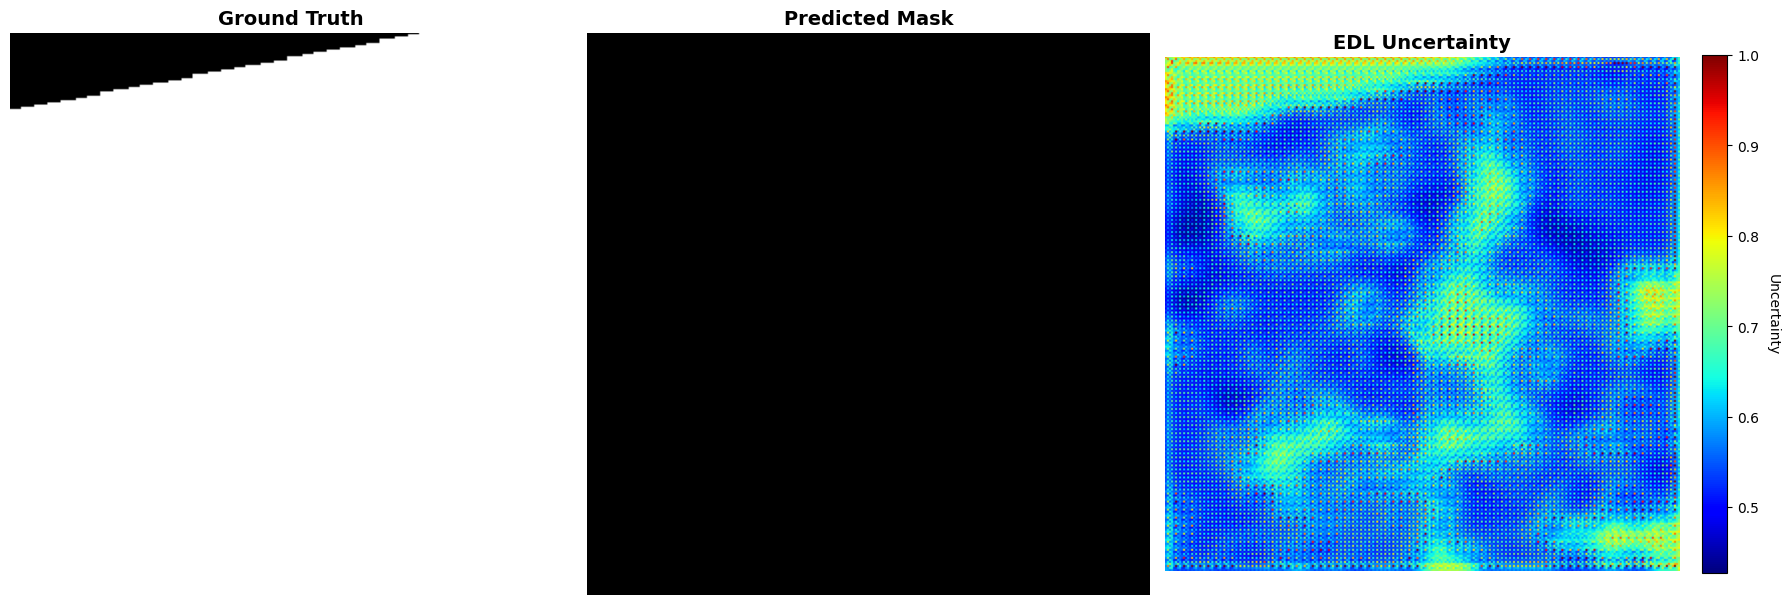

In [106]:
import os
import numpy as np
import matplotlib.pyplot as plt

vis_dir = 'vis/ChangeFormer/maps'
batch_id = 8

gt_path = os.path.join(vis_dir, f'{batch_id}_gt.npy')
pred_path = os.path.join(vis_dir, f'{batch_id}_pred.npy')
unc_path = os.path.join(vis_dir, f'{batch_id}_unc.npy')
prob_path = os.path.join(vis_dir, f'{batch_id}_prob.npy')   # Probability map

if os.path.exists(gt_path):

    gt = np.squeeze(np.load(gt_path))
    pred = np.squeeze(np.load(pred_path))
    unc = np.squeeze(np.load(unc_path))

    if os.path.exists(prob_path):
        prob = np.squeeze(np.load(prob_path))
    else:
        prob = None

    if prob is not None:
        fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    else:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Ground Truth
    axes[0].imshow(gt, cmap='gray')
    axes[0].set_title("Ground Truth", fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # Prediction
    axes[1].imshow(pred, cmap='gray')
    axes[1].set_title("Predicted Mask", fontsize=14, fontweight='bold')
    axes[1].axis('off')

    # Probability
    if prob is not None:
        im_prob = axes[2].imshow(prob, cmap='viridis', vmin=0, vmax=1)
        axes[2].set_title("Probability Map", fontsize=14, fontweight='bold')
        axes[2].axis('off')
        cbar_prob = fig.colorbar(im_prob, ax=axes[2], fraction=0.046, pad=0.04)
        cbar_prob.set_label("Probability", rotation=270, labelpad=15)

        unc_ax = axes[3]
    else:
        unc_ax = axes[2]

    # Uncertainty
    im_unc = unc_ax.imshow(unc, cmap='jet')
    unc_ax.set_title("EDL Uncertainty", fontsize=14, fontweight='bold')
    unc_ax.axis('off')
    cbar_unc = fig.colorbar(im_unc, ax=unc_ax, fraction=0.046, pad=0.04)
    cbar_unc.set_label("Uncertainty", rotation=270, labelpad=15)

    plt.tight_layout()

    output_filename = f'batch_{batch_id}_results.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()

In [107]:
import os

target_file = "batch_99_results.png"
search_dir = "/kaggle/working"

print(f"Searching for '{target_file}'...")
found = False

for root, dirs, files in os.walk(search_dir):
    if target_file in files:
        absolute_path = os.path.join(root, target_file)
        print(f"\n Found it!")
        print(f"Absolute Path: {absolute_path}")
        found = True
        break

if not found:
    print(f"\n File '{target_file}' not found in {search_dir}.")
    print("Make sure you ran the plotting script cell successfully first.")

Searching for 'batch_99_results.png'...

 Found it!
Absolute Path: /kaggle/working/ChangeFormer/batch_99_results.png


In [176]:
import os
print(len([f for f in os.listdir('vis/ChangeFormer/maps') if f.endswith('_pred.npy')]))

804


In [1]:
!git clone https://github.com/Ishant-7678/ChangeFormer.git
%cd ChangeFormer

Cloning into 'ChangeFormer'...
remote: Enumerating objects: 1286, done.
remote: Counting objects: 100% (189/189), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 1286 (delta 119), reused 119 (delta 81), pack-reused 1097 (from 1)
Receiving objects: 100% (1286/1286), 14.03 MiB | 34.30 MiB/s, done.
Resolving deltas: 100% (719/719), done.
/kaggle/working/ChangeFormer


In [19]:
import os

print(os.path.exists("/kaggle/working/list/train.txt"))
print(os.listdir("/kaggle/working"))

False
['ChangeFormer', '.virtual_documents']


In [20]:
import os
import random

DATASET = "/kaggle/input/datasets/ishantthakral/floood/BIFA_DATASET"

# Verify folders
print(os.listdir(DATASET))

files = sorted(os.listdir(os.path.join(DATASET, "A")))
files = [f for f in files if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif"))]

random.shuffle(files)

n = len(files)

train = files[:int(0.7 * n)]
val = files[int(0.7 * n):int(0.85 * n)]
test = files[int(0.85 * n):]

LIST_DIR = "/kaggle/working/list"
os.makedirs(LIST_DIR, exist_ok=True)

for name, data in [
    ("train.txt", train),
    ("val.txt", val),
    ("test.txt", test),
]:
    with open(os.path.join(LIST_DIR, name), "w") as f:
        f.write("\n".join(data))

print("Done!")
print(os.listdir(LIST_DIR))

['label', 'B', 'A', 'list']
Done!
['test.txt', 'val.txt', 'train.txt']


In [21]:
import os
print(os.listdir("/kaggle/working/list"))

['test.txt', 'val.txt', 'train.txt']


In [25]:
!sed -n '1,180p' /kaggle/working/ChangeFormer/datasets/CD_dataset.py

"""
变化检测数据集
"""

import os
from PIL import Image
import numpy as np

from torch.utils import data

from datasets.data_utils import CDDataAugmentation


"""
CD data set with pixel-level labels；
├─image
├─image_post
├─label
└─list
"""
IMG_FOLDER_NAME = "A"
IMG_POST_FOLDER_NAME = 'B'
LIST_FOLDER_NAME = 'list'
ANNOT_FOLDER_NAME = "Label"

IGNORE = 255

label_suffix='.png' # jpg for gan dataset, others : png

def load_img_name_list(dataset_path):
    img_name_list = np.loadtxt(dataset_path, dtype=str)
    if img_name_list.ndim == 2:
        return img_name_list[:, 0]
    return img_name_list


def load_image_label_list_from_npy(npy_path, img_name_list):
    cls_labels_dict = np.load(npy_path, allow_pickle=True).item()
    return [cls_labels_dict[img_name] for img_name in img_name_list]


def get_img_post_path(root_dir,img_name):
    return os.path.join(root_dir, IMG_POST_FOLDER_NAME, img_name)


def get_img_path(root_dir, img_name):
    return os.path.join(root_dir, IMG_FOLDER_NAME, img_nam

In [26]:
!mkdir -p /kaggle/working/list

In [27]:
!cp /kaggle/input/datasets/ishantthakral/floood/BIFA_DATASET/list/train.txt /kaggle/working/list/
!cp /kaggle/input/datasets/ishantthakral/floood/BIFA_DATASET/list/val.txt /kaggle/working/list/
!cp /kaggle/input/datasets/ishantthakral/floood/BIFA_DATASET/list/test.txt /kaggle/working/list/

In [28]:
!ls -l /kaggle/working/list

total 288
-rw-r--r-- 1 root root   2090 Jul  4 04:52 test.txt
-rw-r--r-- 1 root root 261169 Jul  4 04:52 train.txt
-rw-r--r-- 1 root root  27961 Jul  4 04:52 val.txt


In [30]:
!sed -n '1,200p' /kaggle/working/ChangeFormer/data_config.py


class DataConfig:
    data_name = ""
    root_dir = ""
    label_transform = ""
    def get_data_config(self, data_name):
        self.data_name = data_name
        if data_name == 'LEVIR':
            self.label_transform = "norm"
            self.root_dir = '/media/lidan/ssd2/CDData/LEVIR-CD256/'
        elif data_name == 'DSIFN':
            self.label_transform = "norm"
            self.root_dir = '/media/lidan/ssd2/CDData/DSIFN_256/'
        elif data_name == 'WHU':
            self.label_transform = "norm"
            self.root_dir = '/media/lidan/ssd2/CDData/WHU-CD-256/'
        elif data_name == 'CDD':
            self.label_transform = "norm"
            self.root_dir = '/media/lidan/ssd2/CDData/CDD-CD-256/'
        elif data_name == 'TYPO':
            self.label_transform = "norm"
            self.root_dir = '/media/lidan/ssd2/CDData/TYPO/'
        elif data_name == 'quick_start_LEVIR':
            self.root_dir = './samples_LEVIR/'
        elif data_name == 'quick_start_DS

In [31]:
!sed -i 's|/kaggle/input/datasets/madhurgopal/s1gdata/S1GFloods|/kaggle/input/datasets/ishantthakral/floood/BIFA_DATASET|g' /kaggle/working/ChangeFormer/data_config.py

In [35]:
!python /kaggle/working/ChangeFormer/main_cd.py \
--img_size 256 \
--loss ce \
--batch_size 2 \
--num_workers 0 \
--max_epochs 5 \
--data_name S1GFloods \
--net_G ChangeFormerV6 \
--embed_dim 224 \
--gpu_ids 0 \
--lr 0.0001 \
--optimizer adamw

True
[0]
initialize network with normal
cuda:0
================ (Sat Jul  4 04:56:58 2026) ================
gpu_ids: [0] project_name: ChangeFormer checkpoint_root: checkpoints vis_root: vis num_workers: 0 dataset: CDDataset data_name: S1GFloods batch_size: 2 split: train split_val: val img_size: 256 shuffle_AB: False n_class: 2 embed_dim: 224 pretrain: None multi_scale_train: False multi_scale_infer: False multi_pred_weights: [0.5, 0.5, 0.5, 0.8, 1.0] net_G: ChangeFormerV6 loss: ce optimizer: adamw lr: 0.0001 max_epochs: 5 lr_policy: linear lr_decay_iters: 100 checkpoint_dir: checkpoints/ChangeFormer vis_dir: vis/ChangeFormer 

training from scratch...


lr: 0.0001000
 
  0%|                                                  | 0/2486 [00:00<?, ?it/s]
Traceback (most recent call last):
  File "/kaggle/working/ChangeFormer/main_cd.py", line 83, in <module>
    train(args)
  File "/kaggle/working/ChangeFormer/main_cd.py", line 15, in train
    model.train_models()
  File "/kaggle/working/

In [33]:
import os

print(os.listdir("/kaggle/input/datasets/ishantthakral/floood/BIFA_DATASET/A")[:10])

['1111004_93e7de280ea65cdb9ccd82800173dbb2.png', '1111005_5bb2fa74e28f5b13bfa813e22f490998.png', '1111004_10caf7340d3d55da86a0d30d43441ca7.png', '1111004_8c696b6452495844ae90ada0ba867cb9.png', '1111004_32131e083b1f5a118f54940db02c8d87.png', '1111004_f511788cc8f15f4087b5714bd17b0d9d.png', '1111004_c651582170bd58faaaa5b103a4b5eb0a.png', '1111004_abb754201c3a5e20bf45a47621f38167.png', '1111005_17c9482f275f5470b84dce5373e2768c.png', '1111004_33c6cad210615a10abf7f7b15b1b88c2.png']


In [34]:
import os
import random

DATASET = "/kaggle/input/datasets/ishantthakral/floood/BIFA_DATASET"

files = [f for f in os.listdir(os.path.join(DATASET, "A"))
         if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif"))]

random.shuffle(files)

n = len(files)
train = files[:int(0.7*n)]
val = files[int(0.7*n):int(0.85*n)]
test = files[int(0.85*n):]

os.makedirs("/kaggle/working/list", exist_ok=True)

for name, data in [("train.txt", train),
                   ("val.txt", val),
                   ("test.txt", test)]:
    with open(f"/kaggle/working/list/{name}", "w") as f:
        f.write("\n".join(data))

print("Done")

Done


In [36]:
!sed -i "s/'Label'/'label'/g" /kaggle/working/ChangeFormer/datasets/CD_dataset.py

In [37]:
!grep -n "get_label_path" -A5 /kaggle/working/ChangeFormer/datasets/CD_dataset.py

50:def get_label_path(root_dir, img_name):
51-    return os.path.join(root_dir, ANNOT_FOLDER_NAME, img_name.replace('.jpg', label_suffix))
52-
53-
54-class ImageDataset(data.Dataset):
55-    """VOCdataloder"""
--
111:        L_path = get_label_path(self.root_dir, self.img_name_list[index % self.A_size])
112-
113-        label = np.array(Image.open(L_path), dtype=np.uint8)
114-        # if you are getting error because of dim mismatch ad [:,:,0] at the end
115-
116-        #  二分类中，前景标注为255


In [39]:
!grep -n "def get_label_path" -A5 /kaggle/working/ChangeFormer/datasets/CD_dataset.py

50:def get_label_path(root_dir, img_name):
51-    return os.path.join(root_dir, ANNOT_FOLDER_NAME, img_name.replace('.jpg', label_suffix))
52-
53-
54-class ImageDataset(data.Dataset):
55-    """VOCdataloder"""


In [40]:
!grep -n "Label" /kaggle/working/ChangeFormer/datasets/CD_dataset.py

24:ANNOT_FOLDER_NAME = "Label"


In [41]:
!sed -i 's/ANNOT_FOLDER_NAME = "Label"/ANNOT_FOLDER_NAME = "label"/g' /kaggle/working/ChangeFormer/datasets/CD_dataset.py

In [47]:
!python /kaggle/working/ChangeFormer/main_cd.py \
--img_size 256 \
--loss ce \
--batch_size 2 \
--num_workers 0 \
--max_epochs 5 \
--data_name S1GFloods \
--net_G ChangeFormerV6 \
--embed_dim 224 \
--gpu_ids 0 \
--lr 0.0001 \
--optimizer adamw

True
[0]
initialize network with normal
cuda:0
================ (Sat Jul  4 05:06:29 2026) ================
gpu_ids: [0] project_name: ChangeFormer checkpoint_root: checkpoints vis_root: vis num_workers: 0 dataset: CDDataset data_name: S1GFloods batch_size: 2 split: train split_val: val img_size: 256 shuffle_AB: False n_class: 2 embed_dim: 224 pretrain: None multi_scale_train: False multi_scale_infer: False multi_pred_weights: [0.5, 0.5, 0.5, 0.8, 1.0] net_G: ChangeFormerV6 loss: ce optimizer: adamw lr: 0.0001 max_epochs: 5 lr_policy: linear lr_decay_iters: 100 checkpoint_dir: checkpoints/ChangeFormer vis_dir: vis/ChangeFormer 

training from scratch...


lr: 0.0001000
 
100%|███████████████████████████████████████| 2486/2486 [25:49<00:00,  1.60it/s]
Is_training: True. Epoch 0 / 4, epoch_mF1= 0.49931
acc: 0.98217 miou: 0.49300 mf1: 0.49931 iou_0: 0.00382 iou_1: 0.98217 F1_0: 0.00762 F1_1: 0.99100 precision_0: 0.07254 precision_1: 0.98303 recall_0: 0.00402 recall_1: 0.99911 

Begin eval

In [53]:
!find /kaggle/working -name "*.pth"

In [54]:
!find /kaggle/working -type d -name "checkpoints"

/kaggle/working/ChangeFormer/checkpoints


In [55]:
!find /kaggle/working/ChangeFormer/checkpoints -type f

/kaggle/working/ChangeFormer/checkpoints/ChangeFormer/val_acc.npy
/kaggle/working/ChangeFormer/checkpoints/ChangeFormer/best_ckpt.pt
/kaggle/working/ChangeFormer/checkpoints/ChangeFormer/last_ckpt.pt
/kaggle/working/ChangeFormer/checkpoints/ChangeFormer/train_acc.npy
/kaggle/working/ChangeFormer/checkpoints/ChangeFormer/log.txt


In [56]:
!grep -R "latest.pth" -n /kaggle/working/ChangeFormer

In [57]:
!grep -R "last_ckpt.pt" -n /kaggle/working/ChangeFormer

/kaggle/working/ChangeFormer/models/trainer.py:130:    def _load_checkpoint(self, ckpt_name='last_ckpt.pt'):
/kaggle/working/ChangeFormer/models/trainer.py:248:        self._save_checkpoint(ckpt_name='last_ckpt.pt')
grep: /kaggle/working/ChangeFormer/models/__pycache__/trainer.cpython-312.pyc: binary file matches


In [58]:
!grep -R "best_ckpt.pt" -n /kaggle/working/ChangeFormer

/kaggle/working/ChangeFormer/demo_LEVIR.py:43:    parser.add_argument('--checkpoint_name', default='best_ckpt.pt', type=str)
/kaggle/working/ChangeFormer/eval_cd.py:39:    parser.add_argument('--checkpoint_name', default='best_ckpt.pt', type=str)
/kaggle/working/ChangeFormer/README.md:163:checkpoint_name=best_ckpt.pt
/kaggle/working/ChangeFormer/models/trainer.py:257:            self._save_checkpoint(ckpt_name='best_ckpt.pt')
grep: /kaggle/working/ChangeFormer/models/__pycache__/trainer.cpython-312.pyc: binary file matches
/kaggle/working/ChangeFormer/models/basic_model.py:28:    def load_checkpoint(self, checkpoint_name='best_ckpt.pt'):
/kaggle/working/ChangeFormer/models/evaluator.py:63:    def _load_checkpoint(self, checkpoint_name='best_ckpt.pt'):
/kaggle/working/ChangeFormer/models/evaluator.py:156:    def eval_models(self,checkpoint_name='best_ckpt.pt'):
/kaggle/working/ChangeFormer/demo_DSIFN.py:43:    parser.add_argument('--checkpoint_name', default='best_ckpt.pt', type=str)
/k

In [108]:
%cd /kaggle/working/ChangeFormer

/kaggle/working/ChangeFormer


In [109]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   data_config.py
	modified:   datasets/CD_dataset.py
	modified:   models/evaluator.py
	modified:   models/networks.py
	modified:   models/trainer.py

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	YOUR_OUTPUT_LIST_FOLDER/
	batch_4_results.png
	batch_5_results.png
	batch_8_results.png
	batch_95_results.png
	batch_98_results.png
	batch_99_results.png
	checkpoints/
	datasets/__init__.py
	pretrained/
	vis/ChangeFormer/

no changes added to commit (use "git add" and/or "git commit -a")


In [110]:
!git add data_config.py
!git add datasets/CD_dataset.py
!git add datasets/__init__.py
!git add models/evaluator.py
!git add models/networks.py
!git add models/trainer.py

In [111]:
!git commit -m "Add BIFA dataset support and probability map generation"

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@a57c0ca4e6d5.(none)')


In [112]:
!git config --global user.name "Ishant-7678"
!git config --global user.email "itsmehaa13@gmail.com"

In [113]:
!git commit -m "Add BIFA dataset support and probability map generation"

[main 50aa237] Add BIFA dataset support and probability map generation
 6 files changed, 149 insertions(+), 211 deletions(-)
 create mode 100644 datasets/__init__.py
 rewrite models/evaluator.py (82%)


In [ ]:
!git push origin main

Username for 'https://github.com': 